In [1]:
pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ✅ Install dependencies in Google Colab
!pip install numpy matplotlib scipy torch torchvision tensorboard tqdm --quiet

# ✅ Clone SpikingJelly with activation_based support
!rm -rf spikingjelly
!git clone https://github.com/fangwei123456/spikingjelly.git
%cd spikingjelly
!python setup.py bdist_wheel
!pip install dist/*.whl --quiet
%cd ..


Cloning into 'spikingjelly'...
remote: Enumerating objects: 18423, done.
remote: Counting objects: 100% (1222/1222), done.
remote: Compressing objects: 100% (239/239), done.
remote: Total 18423 (delta 1033), reused 983 (delta 983), pack-reused 17201 (from 3)
Receiving objects: 100% (18423/18423), 46.43 MiB | 4.56 MiB/s, done.
Resolving deltas: 100% (12597/12597), done.
Updating files: 100% (1353/1353), done.
/Users/gecsanreyes/Desktop/verilog/EE533/EE533-Final/spikingjelly
/opt/homebrew/Cellar/python@3.14/3.14.4/Frameworks/Python.framework/Versions/3.14/Resources/Python.app/Contents/MacOS/Python: can't open file '/Users/gecsanreyes/Desktop/verilog/EE533/EE533-Final/spikingjelly/setup.py': [Errno 2] No such file or directory
zsh:1: no matches found: dist/*.whl
/Users/gecsanreyes/Desktop/verilog/EE533/EE533-Final


In [3]:
from spikingjelly.activation_based import neuron, encoding, learning, functional
print("✅ SpikingJelly activation_based modules loaded!")


W0430 15:10:16.406000 71093 torch/_library/triton.py:53] Triton not available, find_triton_kernels = []
W0430 15:10:16.411000 71093 torch/_library/triton.py:53] Triton not available, find_triton_kernels = []
W0430 15:10:16.415000 71093 torch/_library/triton.py:53] Triton not available, find_triton_kernels = []
W0430 15:10:16.416000 71093 torch/_library/triton.py:53] Triton not available, find_triton_kernels = []
W0430 15:10:16.420000 71093 torch/_library/triton.py:53] Triton not available, find_triton_kernels = []
W0430 15:10:16.421000 71093 torch/_library/triton.py:53] Triton not available, find_triton_kernels = []


✅ SpikingJelly activation_based modules loaded!


Setup & Imports, Load and Preprocess MNIST Dataset:

In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
from spikingjelly.activation_based import neuron, encoding, functional, learning
from torch import nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


100%|██████████| 9.91M/9.91M [00:02<00:00, 3.78MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 437kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.76MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.25MB/s]


Define the SNN Architecture:
2 Linear layers,
1 Hidden layer with 128 neurons,
1 Output layer with 10 neurons,
2 Spiking (LIF) activations

In [5]:
class SNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = encoding.PoissonEncoder()
        self.fc1 = nn.Linear(28*28, 800)
        self.sn1 = neuron.LIFNode()
        self.fc2 = nn.Linear(800, 10)
        self.sn2 = neuron.LIFNode()

    def forward(self, x, time_window=20):
        x = x.view(x.size(0), -1)
        out_spike = 0
        for t in range(time_window):
            encoded = self.encoder(x)
            out = self.fc1(encoded)
            out = self.sn1(out)
            out = self.fc2(out)
            out = self.sn2(out)
            out_spike += out
        return out_spike / time_window


Initialize Model, Loss, Optimizer:

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


Training Loop (Basic Version):

In [7]:
def train(model, train_loader, epochs=1):
    model.train()
    for epoch in range(epochs):
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            functional.reset_net(model)

            if batch_idx % 100 == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}, Loss: {loss.item():.4f}")


Resizing and Visualizing MNIST Images:

🧠 Accuracy for 4x4 input: 52.87%


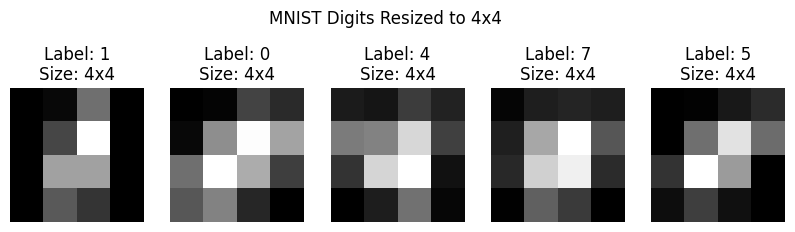

🧠 Accuracy for 7x7 input: 79.15%


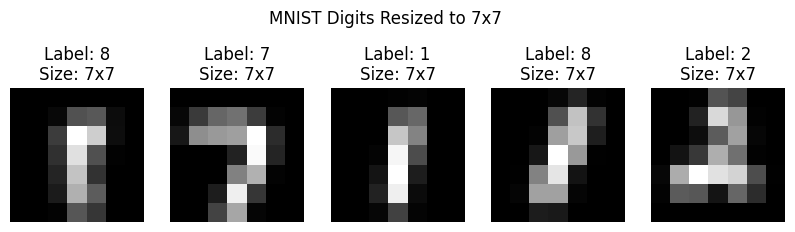

🧠 Accuracy for 14x14 input: 90.81%


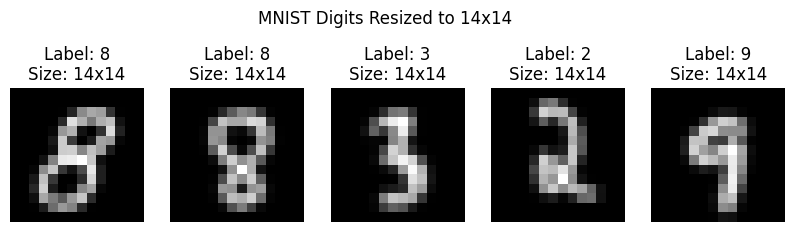

🧠 Accuracy for 28x28 input: 92.72%


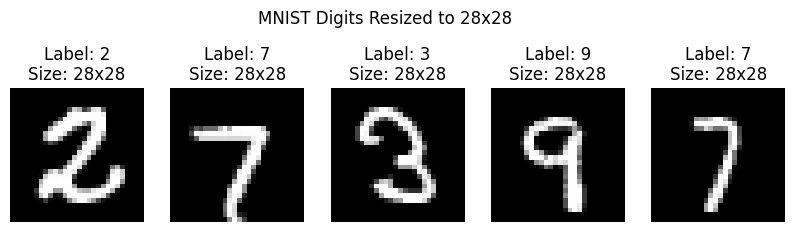

In [8]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from spikingjelly.activation_based import neuron, encoding, functional, surrogate

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T = 10  # time steps
epochs = 1
batch_size = 64
lr = 1e-3

resize_sizes = [(4, 4), (7, 7), (14, 14), (28, 28)]
train_loaders = {}
test_loaders = {}

# Define simple SNN model for arbitrary input size
class SNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, 128)
        self.lif1 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())
        self.fc2 = nn.Linear(128, 10)
        self.lif2 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.lif1(x)
        x = self.fc2(x)
        x = self.lif2(x)
        return x

# Loop through each size, create datasets, and evaluate accuracy
for size in resize_sizes:
    transform = transforms.Compose([
        transforms.Resize(size),
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    train_loaders[size] = train_loader
    test_loaders[size] = test_loader

    # Train and evaluate the SNN for this input size
    input_size = size[0] * size[1]
    model = SNN(input_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    encoder = encoding.PoissonEncoder()

    # Train
    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            functional.reset_net(model)
            out_spikes = 0
            for t in range(T):
                encoded = encoder(images)
                out_spikes += model(encoded)
            out_spikes /= T
            loss = criterion(out_spikes, labels)
            loss.backward()
            optimizer.step()

    # Evaluate
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            functional.reset_net(model)
            out_spikes = 0
            for t in range(T):
                out_spikes += model(encoder(images))
            out_spikes /= T
            preds = out_spikes.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    print(f"🧠 Accuracy for {size[0]}x{size[1]} input: {acc:.2f}%")

    # Visualize sample images
    data_iter = iter(train_loader)
    images, labels = next(data_iter)
    fig, axes = plt.subplots(1, 5, figsize=(10, 3))
    for i in range(5):
        axes[i].imshow(images[i].squeeze(), cmap='gray')
        axes[i].set_title(f"Label: {labels[i].item()}\nSize: {size[0]}x{size[1]}")
        axes[i].axis('off')
    plt.suptitle(f"MNIST Digits Resized to {size[0]}x{size[1]}")
    plt.show()



Poisson Encoding with Time Steps:

In [9]:
from spikingjelly.activation_based import neuron, encoding, functional, learning


def train_snn(model, train_loader, T=10, device='cpu', epochs=1):
    model.train()
    encoder = encoding.PoissonEncoder()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = 0

            # ✅ Reset neuron states before each input sample
            functional.reset_net(model)

            # Forward through time steps
            for t in range(T):
                encoded = encoder(images)
                out = model(encoded)
                outputs += out

            outputs /= T
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred = outputs.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}, Accuracy = {100. * correct / total:.2f}%")


input_size = 14 * 14  # update this based on your resized input

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(input_size, 128),
    neuron.LIFNode(),
    nn.Linear(128, 10),
    neuron.LIFNode()
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Use one of the resized loaders, e.g., 14x14
train_loader = train_loaders[(14, 14)]

# Train using 5, 10, 20 time steps
for T in [5, 10, 20]:
    print(f"\nTraining with T = {T} time steps")
    train_snn(model, train_loader, T=T, device=device, epochs=1)



Training with T = 5 time steps
Epoch 1: Loss = 1559.6831, Accuracy = 79.24%

Training with T = 10 time steps
Epoch 1: Loss = 1449.5889, Accuracy = 91.43%

Training with T = 20 time steps
Epoch 1: Loss = 1434.8861, Accuracy = 93.18%


Visualizing MNIST Images With Different Time Steps:

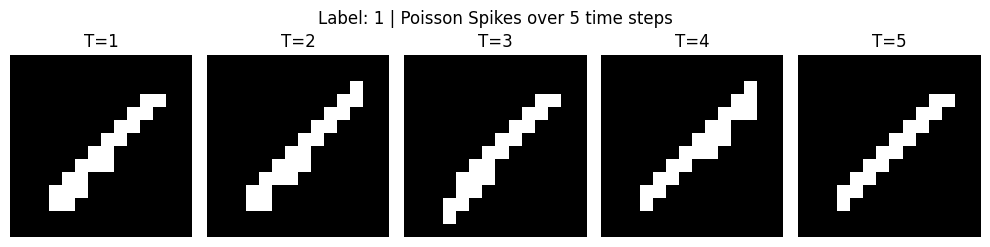

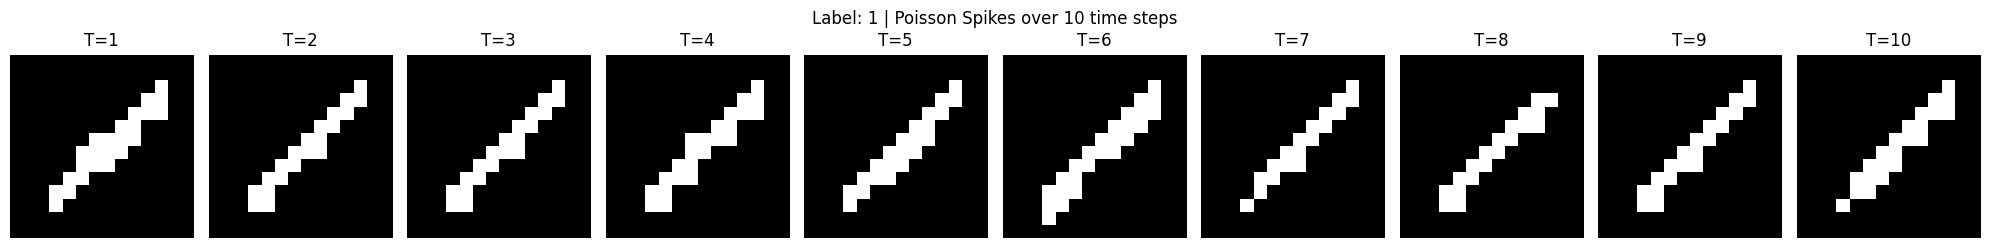

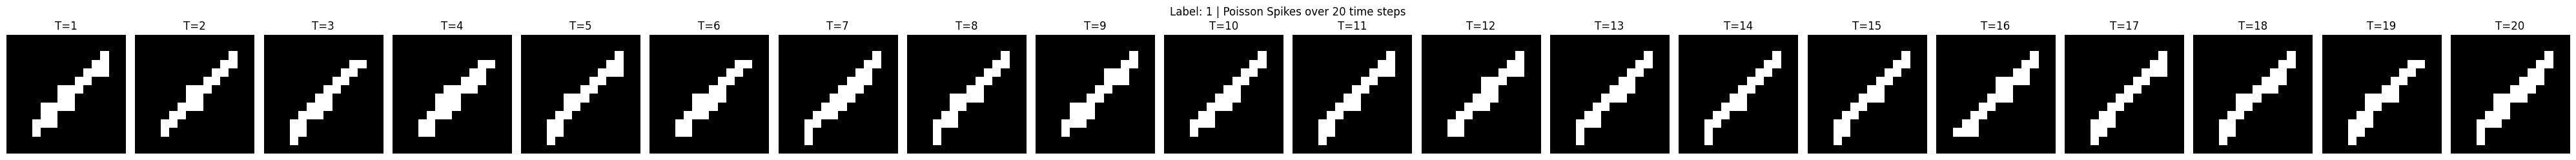

In [10]:
import matplotlib.pyplot as plt

# Get a batch from the loader
images, labels = next(iter(train_loader))
image = images[0]  # Select one image
label = labels[0]

# Encode the image into Poisson spikes over T time steps
encoder = encoding.PoissonEncoder()
T_values = [5, 10, 20]

for T in T_values:
    fig, axes = plt.subplots(1, T, figsize=(T*2, 2.5))
    fig.suptitle(f"Label: {label} | Poisson Spikes over {T} time steps", fontsize=12)

    for t in range(T):
        spike = encoder(image.unsqueeze(0)).squeeze(0).squeeze(0)  # shape: [H, W]
        axes[t].imshow(spike.cpu(), cmap='gray')
        axes[t].set_title(f"T={t+1}")
        axes[t].axis('off')

    plt.tight_layout()
    plt.show()


Visualizing the Poisson Spikes (Raster Plot):

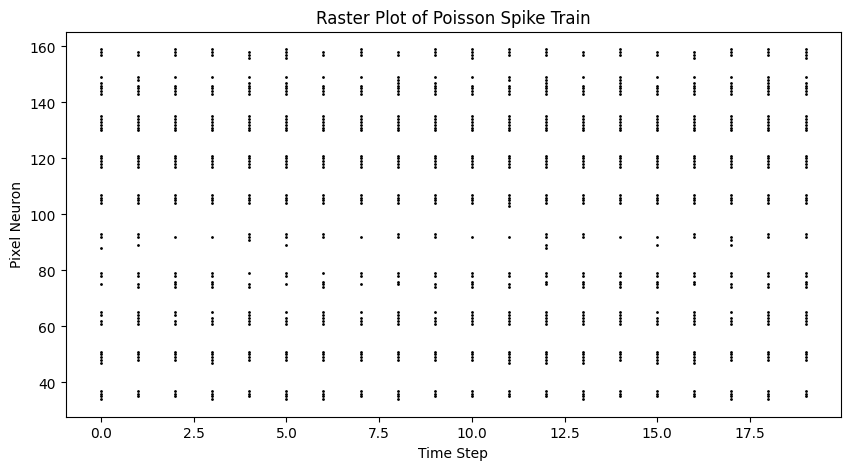

In [11]:
import numpy as np

# Load one sample image from MNIST
example_img, _ = next(iter(train_loader))
example_img = example_img[0]  # Take the first image
T = 20  # Number of time steps

# Initialize Poisson encoder
encoder = encoding.PoissonEncoder()

# Encode over time and store spikes
spike_trains = []
for t in range(T):
    spikes = encoder(example_img.unsqueeze(0))  # Add batch dim
    spike_trains.append(spikes.squeeze().numpy())  # Remove batch dim

# Convert to NumPy array: shape (T, H, W)
spike_array = np.array(spike_trains)

# Optional: Flatten the spatial dims for raster
num_pixels = example_img.numel()
spike_array_flat = spike_array.reshape(T, num_pixels).T  # shape (pixels, T)

# Plot raster
plt.figure(figsize=(10, 5))
for neuron_id, spikes in enumerate(spike_array_flat):
    times = np.where(spikes > 0)[0]
    plt.scatter(times, [neuron_id] * len(times), s=1, color='black')

plt.xlabel("Time Step")
plt.ylabel("Pixel Neuron")
plt.title("Raster Plot of Poisson Spike Train")
plt.show()

Supervised Learning: Surrogate Gradient Descent

Epoch 1 | Loss: 1466.4597 | Accuracy: 88.94%
Epoch 2 | Loss: 1406.7955 | Accuracy: 95.42%
Epoch 3 | Loss: 1396.4411 | Accuracy: 96.80%
Epoch 4 | Loss: 1390.2308 | Accuracy: 97.64%
Epoch 5 | Loss: 1386.3366 | Accuracy: 98.14%


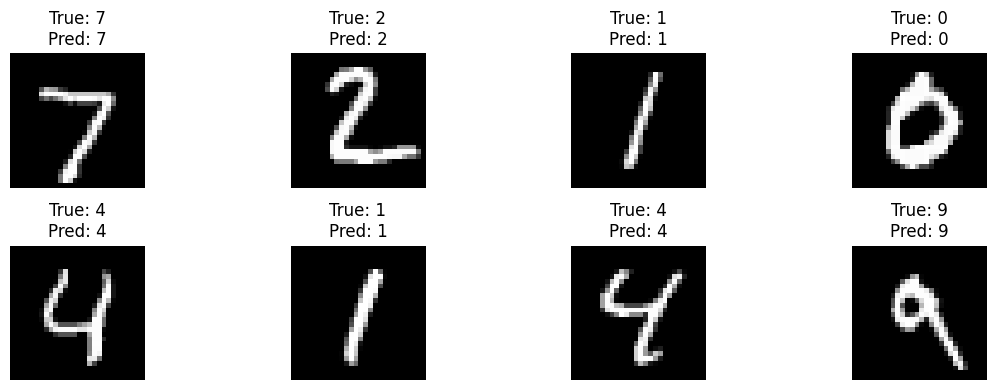

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from spikingjelly.activation_based import neuron, functional, encoding, surrogate

# ========== Setup ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 5
T = 20
batch_size = 64
lr = 1e-3

# ========== Load MNIST ==========
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=False
)

# ========== Define Model ==========
class SNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.lif1 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())
        self.fc2 = nn.Linear(512, 10)
        self.lif2 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.lif1(x)
        x = self.fc2(x)
        x = self.lif2(x)
        return x

model = SNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()
encoder = encoding.PoissonEncoder()

# ========== Training ==========
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        functional.reset_net(model)
        optimizer.zero_grad()

        out_spikes = 0
        for t in range(T):
            spikes = encoder(images)
            out_spikes += model(spikes)
        out_spikes /= T

        loss = loss_fn(out_spikes, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = out_spikes.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f} | Accuracy: {acc:.2f}%")

# ========== Visualization ==========
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

functional.reset_net(model)
out_spikes = 0
for t in range(T):
    spikes = encoder(images)
    out_spikes += model(spikes)
out_spikes /= T

preds = out_spikes.argmax(dim=1)

plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i].cpu().squeeze(), cmap='gray')
    plt.title(f"True: {labels[i].item()}\nPred: {preds[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()



Unsupervised Training: Full Minimal STDP Training Code


🧠 Starting STDP training...
Epoch 1 complete
Epoch 2 complete
Epoch 3 complete
Epoch 4 complete
Epoch 5 complete
✅ STDP training finished!


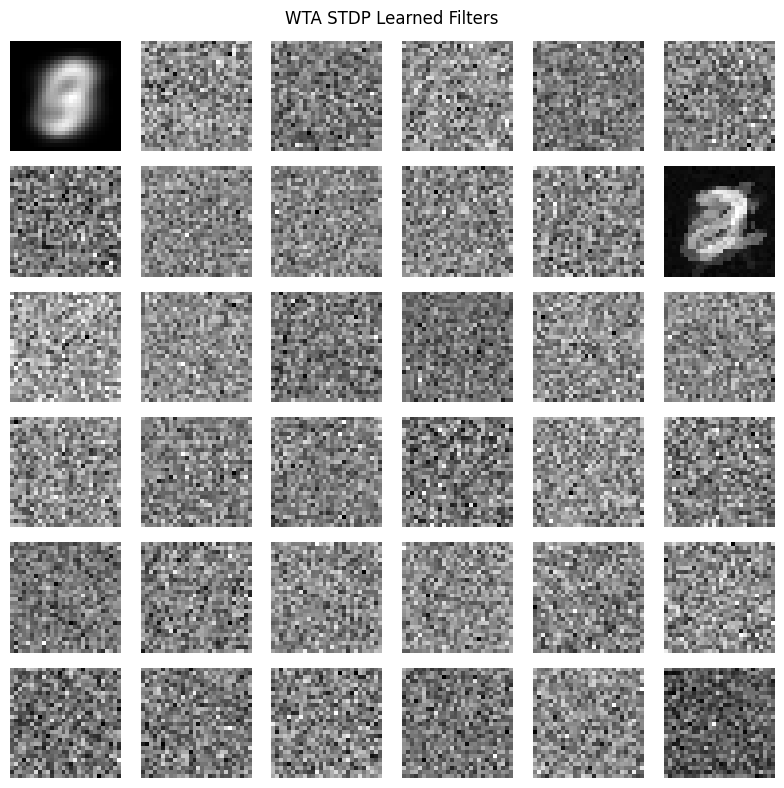


🔁 Training classifier on frozen STDP features...
Epoch 1: Accuracy=10.60%
Epoch 2: Accuracy=14.40%
Epoch 3: Accuracy=20.65%
Epoch 4: Accuracy=25.20%
Epoch 5: Accuracy=33.80%

✅ Final Test Accuracy using STDP features: 39.36%


In [13]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from spikingjelly.activation_based import neuron, encoding, functional

# ========== Hyperparameters ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T = 5                 # Time steps per sample
lr = 1e-3             # STDP learning rate
epochs = 5            # STDP training epochs
num_neurons = 36      # Output neurons / filters
trace_decay = 0.9     # Trace decay for STDP

# ========== Load MNIST (subset for speed) ==========
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_dataset = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform)
subset = Subset(full_dataset, range(2000))
train_loader = DataLoader(subset, batch_size=64, shuffle=True)

test_dataset = torchvision.datasets.MNIST('./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ========== Define STDPNet ==========
class STDPNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(28 * 28, num_neurons, bias=False)
        self.lif = neuron.LIFNode(v_threshold=0.5)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc(x)
        x = self.lif(x)
        return x

model = STDPNet().to(device)
torch.nn.init.normal_(model.fc.weight, mean=0.0, std=0.01)

encoder = encoding.PoissonEncoder()
pre_trace = torch.zeros_like(model.fc.weight.data)

# ========== STDP Update Rule ==========
def stdp_update(pre_spike, post_spike):
    global pre_trace
    pre_trace = trace_decay * pre_trace + pre_spike

    if post_spike.sum() > 0:
        winner = torch.argmax(post_spike)
        post_spike[:] = 0
        post_spike[0, winner] = 1

        dw = torch.einsum('bi,bj->ij', post_spike, pre_trace)
        model.fc.weight.data += lr * dw

# ========== Unsupervised STDP Training ==========
print("\n🧠 Starting STDP training...")
for epoch in range(epochs):
    for images, _ in train_loader:
        images = images.to(device)

        for i in range(images.size(0)):
            functional.reset_net(model)
            for t in range(T):
                spikes = encoder(images[i].unsqueeze(0))  # shape: [1, 1, 28, 28]
                pre_spike = spikes.view(1, -1).float()
                out = model(spikes)
                post_spike = (out > 0).float()
                stdp_update(pre_spike, post_spike)

    with torch.no_grad():
        model.fc.weight.data = torch.nn.functional.normalize(model.fc.weight.data, p=2, dim=1)

    print(f"Epoch {epoch + 1} complete")

print("✅ STDP training finished!")

# ========== Visualize Filters ==========
with torch.no_grad():
    weights = model.fc.weight.data.cpu().numpy()
    fig, axes = plt.subplots(6, 6, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(weights[i].reshape(28, 28), cmap='gray')
        ax.axis('off')
    plt.suptitle("WTA STDP Learned Filters")
    plt.tight_layout()
    plt.show()

# ========== Train Simple Classifier ==========
class ClassifierNet(nn.Module):
    def __init__(self, feature_extractor):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.classifier = nn.Linear(num_neurons, 10)

    def forward(self, x):
        with torch.no_grad():
            x = self.feature_extractor.flatten(x)
            x = self.feature_extractor.fc(x)
            x = torch.relu(x)
        return self.classifier(x)

clf_model = ClassifierNet(model).to(device)
optimizer = torch.optim.Adam(clf_model.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print("\n🔁 Training classifier on frozen STDP features...")
for epoch in range(5):
    clf_model.train()
    total = correct = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        output = clf_model(images)
        loss = criterion(output, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = output.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch + 1}: Accuracy={100 * correct / total:.2f}%")

# ========== Final Evaluation ==========
clf_model.eval()
correct = total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        output = clf_model(images)
        preds = output.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"\n✅ Final Test Accuracy using STDP features: {100 * correct / total:.2f}%")


Quantizing the Weights (Using supervised SNN model): Including raster plots to visualize the spiking behavior of the network

🧠 Training supervised SNN...
Epoch 1: Loss=1464.8228, Accuracy=89.20%
Epoch 2: Loss=1407.0958, Accuracy=95.36%
Epoch 3: Loss=1396.6294, Accuracy=96.77%
Epoch 4: Loss=1390.5084, Accuracy=97.62%
Epoch 5: Loss=1386.5441, Accuracy=98.15%

✅ Full-precision test accuracy: 97.33%

🔍 Quantization Results:
2-bit accuracy: 14.57%


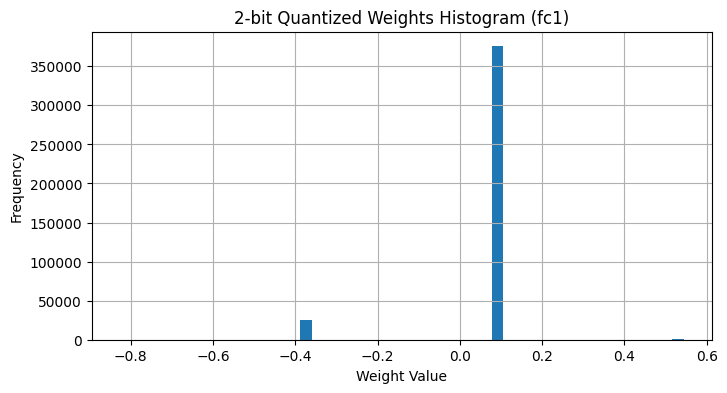

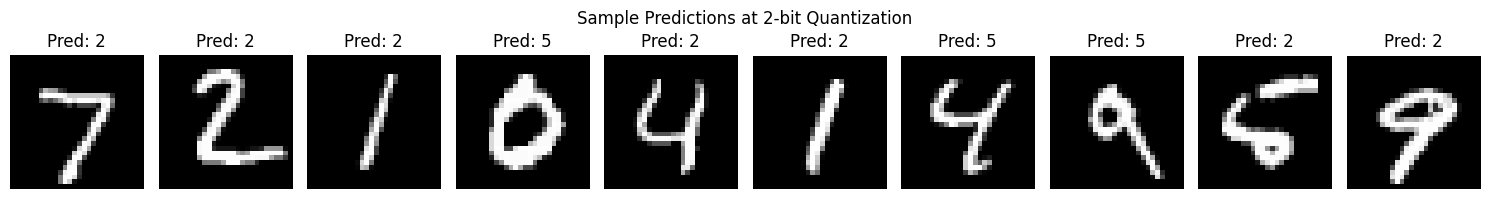

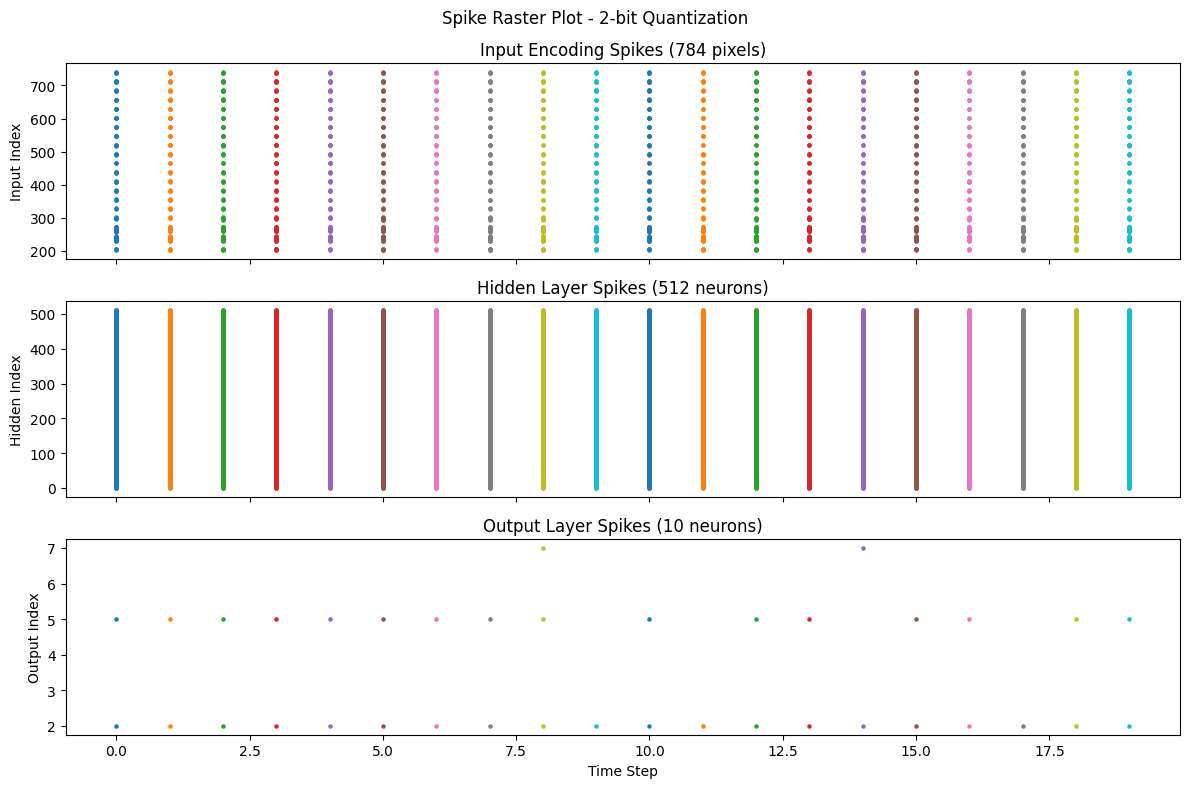

3-bit accuracy: 96.33%


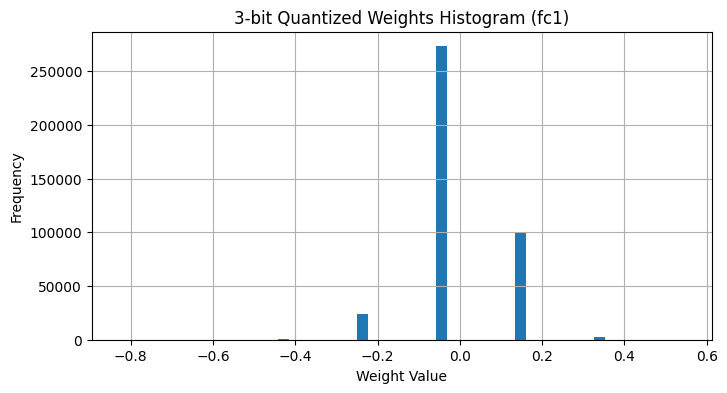

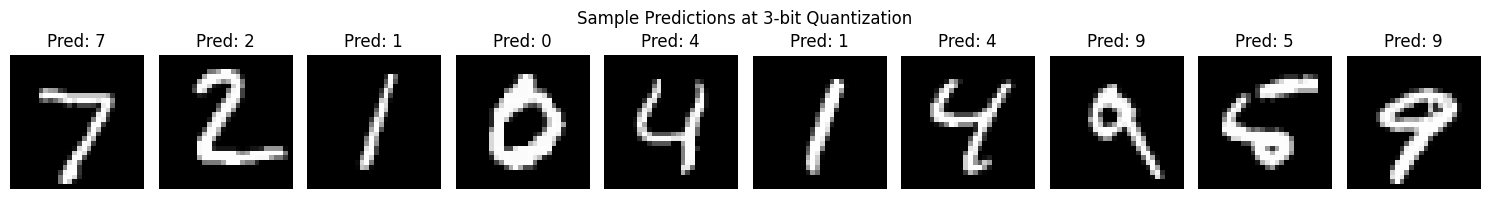

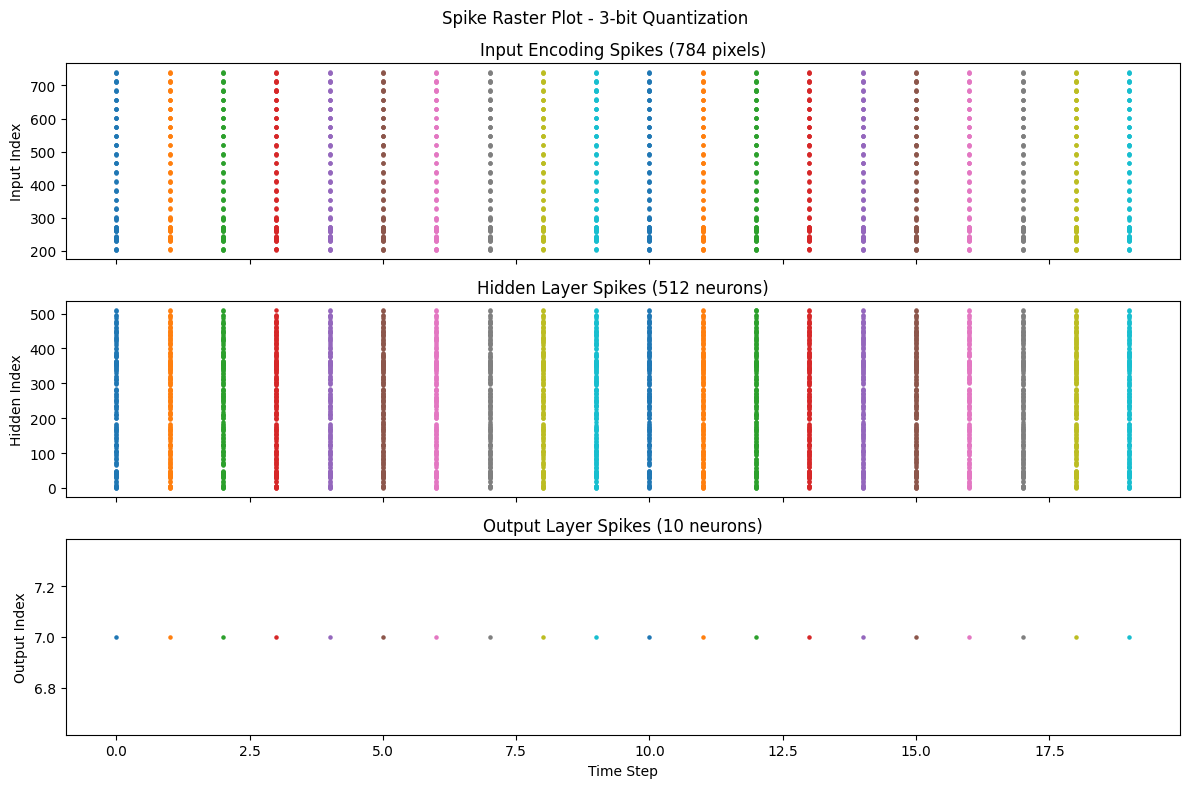

4-bit accuracy: 97.38%


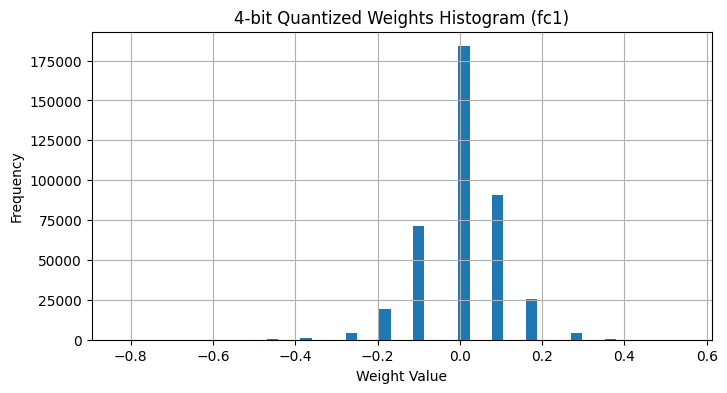

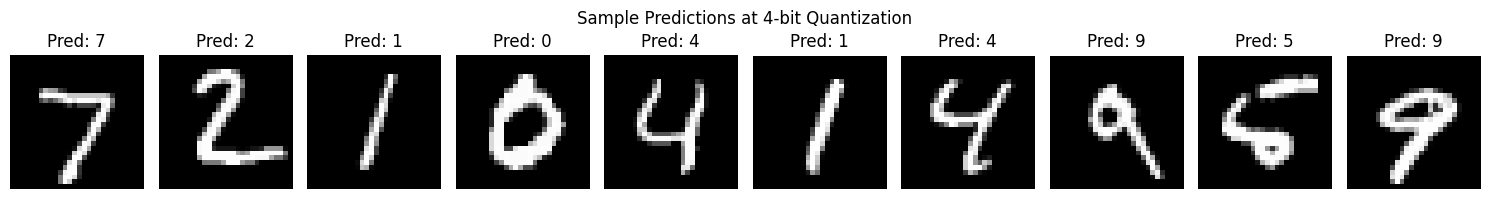

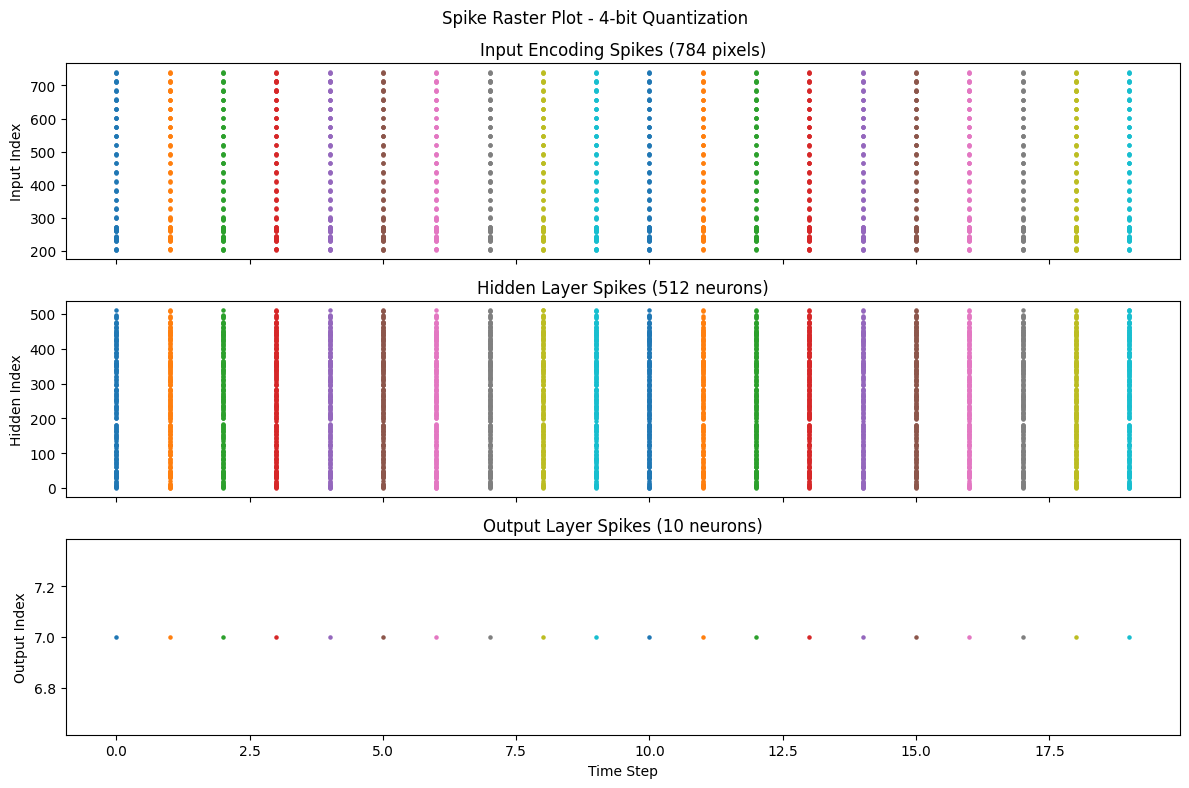

5-bit accuracy: 97.30%


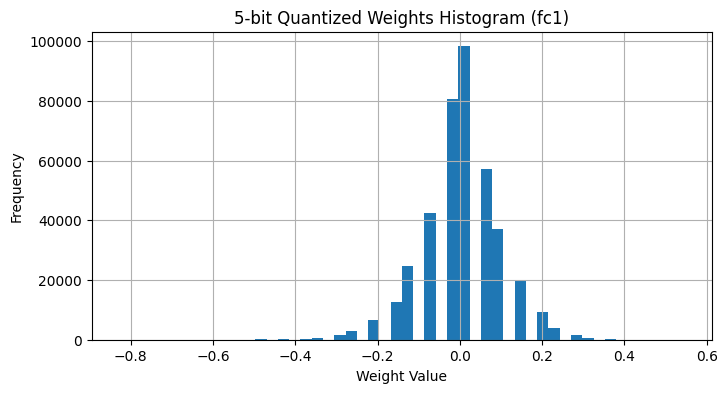

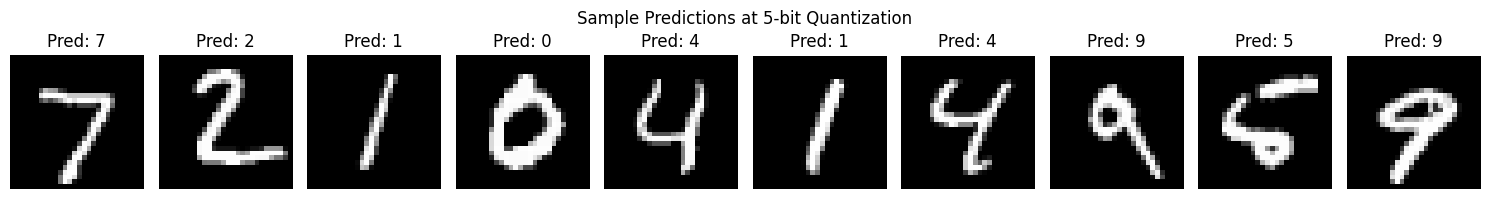

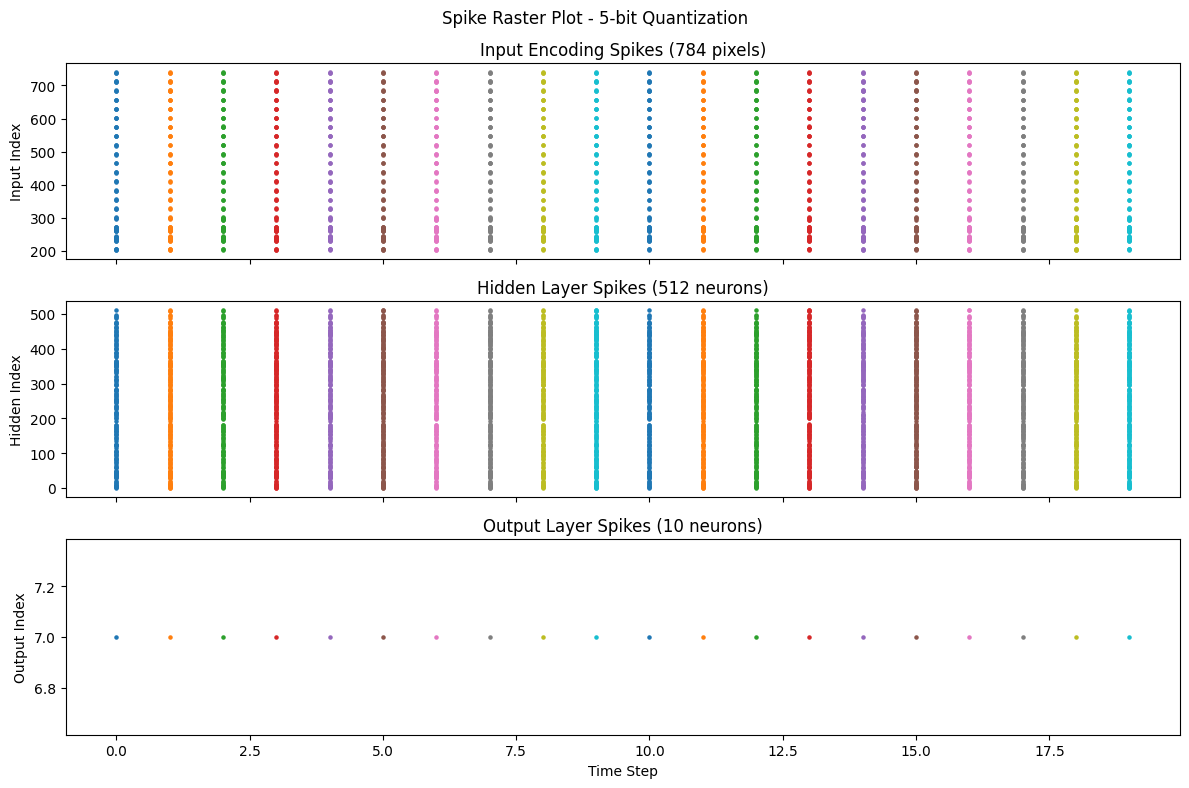

tensor([[-0.2097,  0.1820, -0.2234,  ...,  0.0146,  0.0309,  0.0509],
        [ 0.0250, -0.0893,  0.0863,  ..., -0.0111, -0.1550, -0.2854],
        [-0.1122, -0.1592,  0.0268,  ..., -0.2277, -0.1711,  0.0797],
        ...,
        [ 0.0869, -0.0288,  0.1205,  ...,  0.4291,  0.2026,  0.0589],
        [ 0.1179,  0.0720, -0.1171,  ..., -0.2388,  0.1123, -0.4758],
        [ 0.1484,  0.1179, -0.6900,  ..., -0.4346,  0.1203, -0.2233]])

In [14]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from spikingjelly.activation_based import neuron, encoding, functional, surrogate

# ========== Setup ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T = 20
epochs = 5
batch_size = 64
lr = 1e-3

# ========== Load MNIST ==========
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ========== Supervised SNN ==========
class SNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.lif1 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())
        self.fc2 = nn.Linear(512, 10)
        self.lif2 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.lif1(x)
        x = self.fc2(x)
        x = self.lif2(x)
        return x

model = SNN().to(device)
encoder = encoding.PoissonEncoder()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# ========== Step 4a: Train ==========
print("\U0001f9e0 Training supervised SNN...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        functional.reset_net(model)
        out_spikes = 0
        for t in range(T):
            encoded = encoder(images)
            out_spikes += model(encoded)
        out_spikes /= T
        loss = criterion(out_spikes, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = out_spikes.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}: Loss={total_loss:.4f}, Accuracy={acc:.2f}%")

# ========== Evaluate Full-Precision ==========
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        functional.reset_net(model)
        out_spikes = 0
        for t in range(T):
            out_spikes += model(encoder(images))
        out_spikes /= T
        preds = out_spikes.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

baseline_acc = 100 * correct / total
print(f"\n✅ Full-precision test accuracy: {baseline_acc:.2f}%")

# ========== Step 5: Quantize & Evaluate ==========
def quantize_weights(w, bits):
    levels = 2 ** bits
    w_min = w.min()
    w_max = w.max()
    scale = (w_max - w_min) / (levels - 1)
    return torch.round((w - w_min) / scale) * scale + w_min

# Save original weights
original_fc1 = model.fc1.weight.data.clone()
original_fc2 = model.fc2.weight.data.clone()

# Get one batch of test images for visualization
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)

# ========== Spike Raster Plotting ==========
def plot_supervised_spike_raster(images, model, encoder, T, title="Spike Raster Plot"):
    model.eval()
    with torch.no_grad():
        functional.reset_net(model)
        input_record = []
        hidden_record = []
        output_record = []

        for t in range(T):
            encoded = encoder(images)
            flat = model.flatten(encoded)
            hidden = model.lif1(model.fc1(flat))
            output = model.lif2(model.fc2(hidden))

            input_record.append(flat[0].cpu())
            hidden_record.append(hidden[0].cpu())
            output_record.append(output[0].cpu())

    fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axs[0].set_title("Input Encoding Spikes (784 pixels)")
    axs[1].set_title("Hidden Layer Spikes (512 neurons)")
    axs[2].set_title("Output Layer Spikes (10 neurons)")

    for t in range(T):
        for ax, record in zip(axs, [input_record, hidden_record, output_record]):
            y = torch.where(record[t] > 0)[0].numpy()
            x = [t] * len(y)
            ax.scatter(x, y, s=5)

    axs[2].set_xlabel("Time Step")
    axs[0].set_ylabel("Input Index")
    axs[1].set_ylabel("Hidden Index")
    axs[2].set_ylabel("Output Index")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Quantize and evaluate
bit_levels = [2, 3, 4, 5]
print("\n🔍 Quantization Results:")
for bits in bit_levels:
    # Quantize both layers
    model.fc1.weight.data.copy_(quantize_weights(original_fc1, bits))
    model.fc2.weight.data.copy_(quantize_weights(original_fc2, bits))

    # Evaluate
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            functional.reset_net(model)
            out_spikes = 0
            for t in range(T):
                out_spikes += model(encoder(images))
            out_spikes /= T
            preds = out_spikes.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    print(f"{bits}-bit accuracy: {acc:.2f}%")

    # Plot histogram of quantized weights (fc1)
    plt.figure(figsize=(8, 4))
    plt.hist(model.fc1.weight.data.cpu().flatten(), bins=50)
    plt.title(f"{bits}-bit Quantized Weights Histogram (fc1)")
    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    # Visualize model predictions on test images
    with torch.no_grad():
        functional.reset_net(model)
        out_spikes = 0
        for t in range(T):
            out_spikes += model(encoder(test_images))
        out_spikes /= T
        preds = out_spikes.argmax(dim=1)

    fig, axes = plt.subplots(1, 10, figsize=(15, 2))
    fig.suptitle(f"Sample Predictions at {bits}-bit Quantization")
    for i, ax in enumerate(axes):
        ax.imshow(test_images[i].cpu().squeeze(), cmap='gray')
        ax.set_title(f"Pred: {preds[i].item()}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Plot spike raster
    plot_supervised_spike_raster(test_images[0:1], model, encoder, T, title=f"Spike Raster Plot - {bits}-bit Quantization")

# Restore original weights
model.fc1.weight.data.copy_(original_fc1)
model.fc2.weight.data.copy_(original_fc2)


Quantizing the Weights (Using unsupervised STDPNet model): Including raster plots to visualize the spiking behavior of the network


🔧 2-bit Quantization


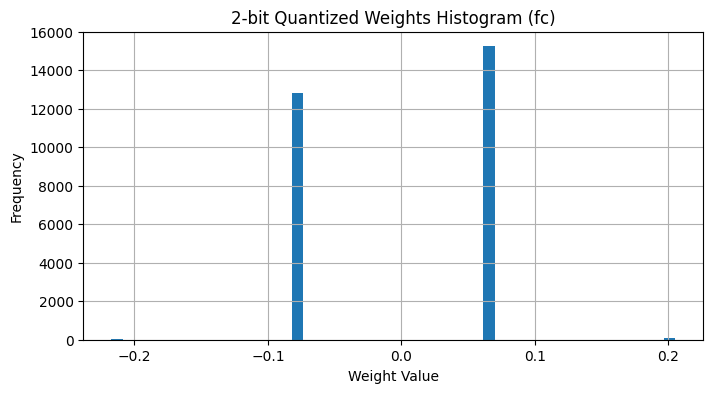

2-bit test accuracy: 29.08%


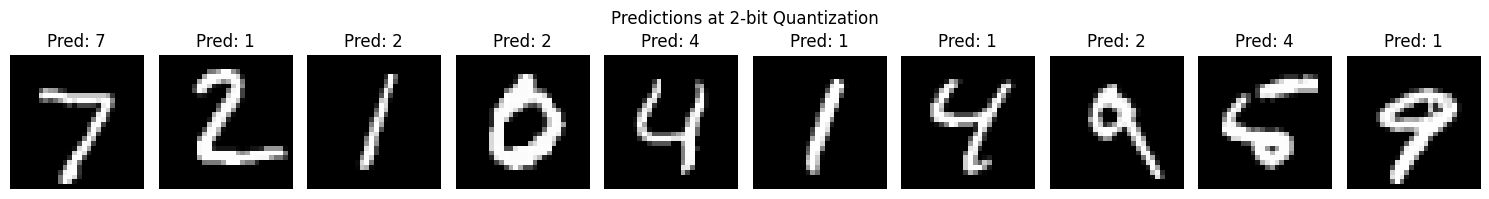

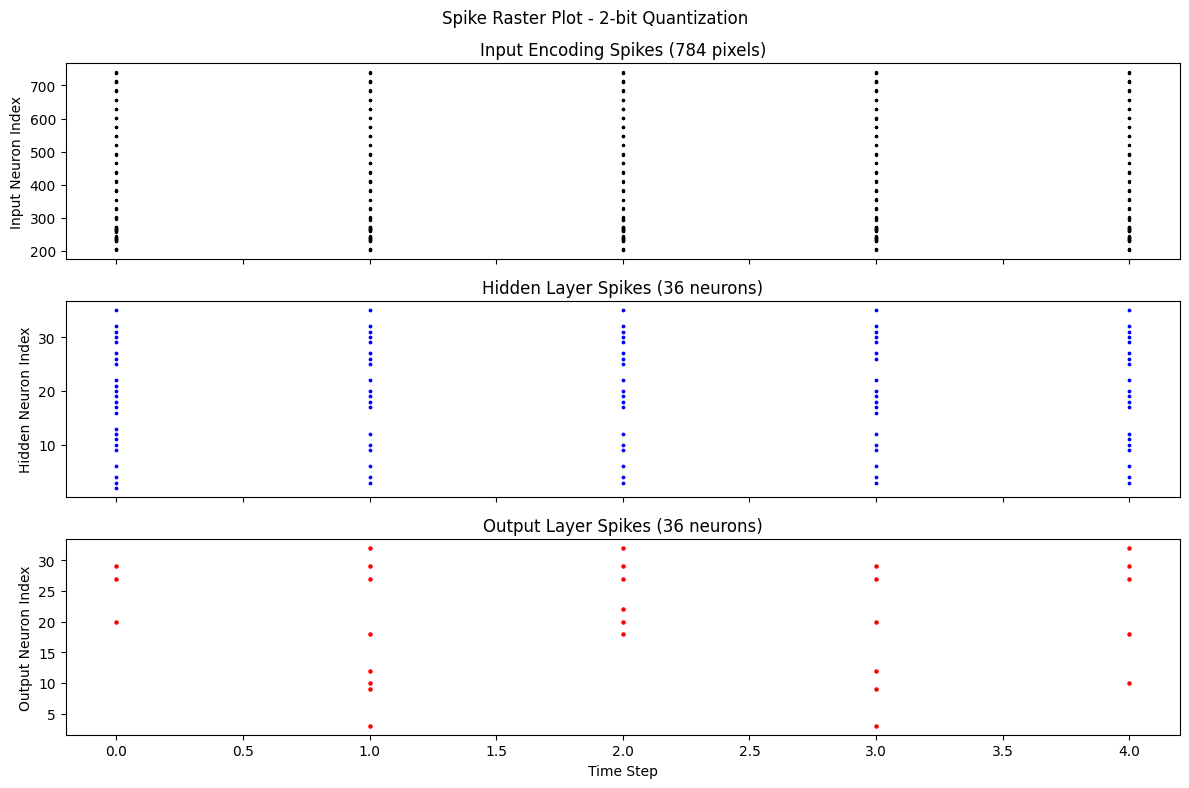


🔧 3-bit Quantization


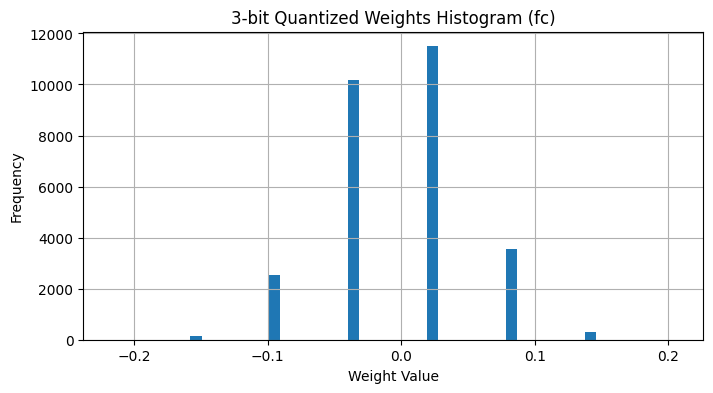

3-bit test accuracy: 24.46%


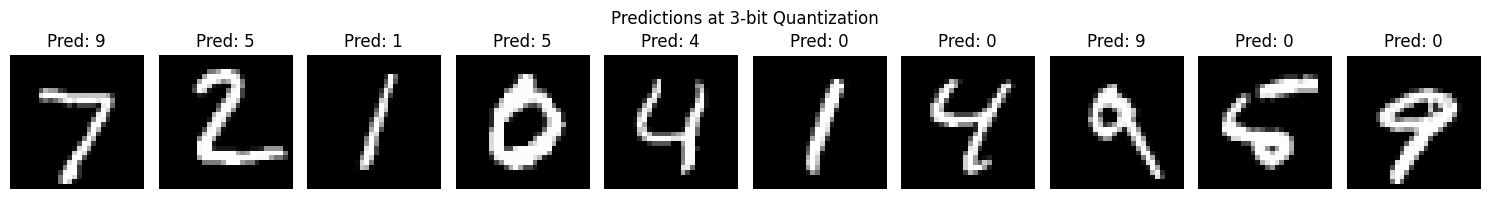

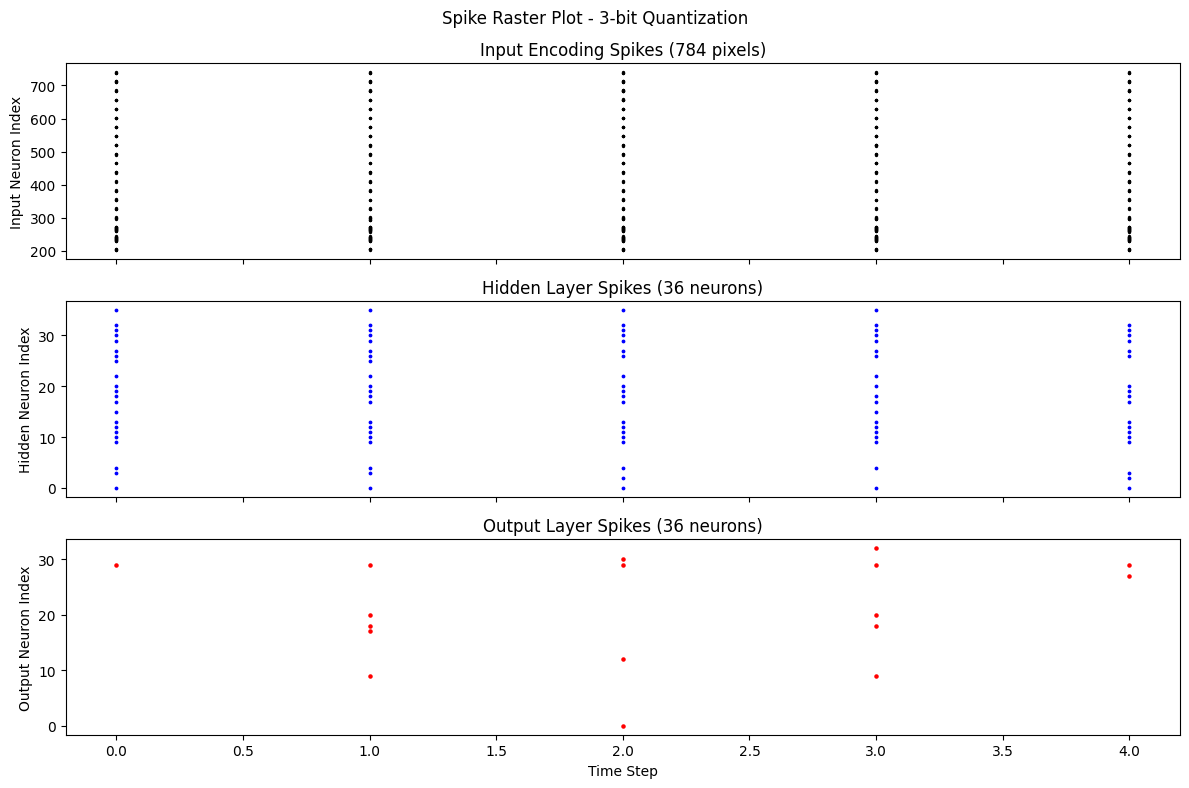


🔧 4-bit Quantization


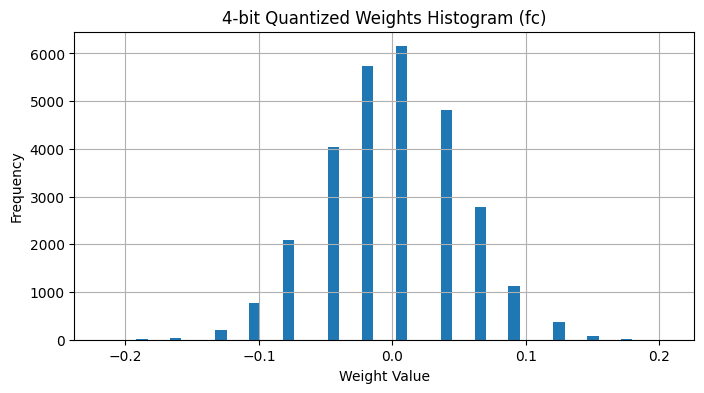

4-bit test accuracy: 27.21%


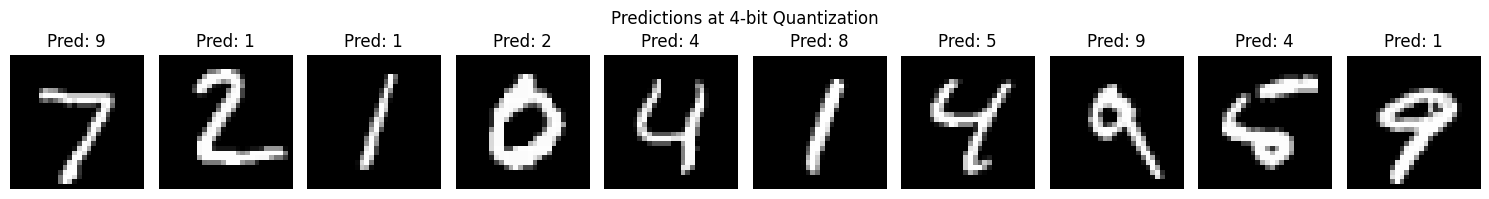

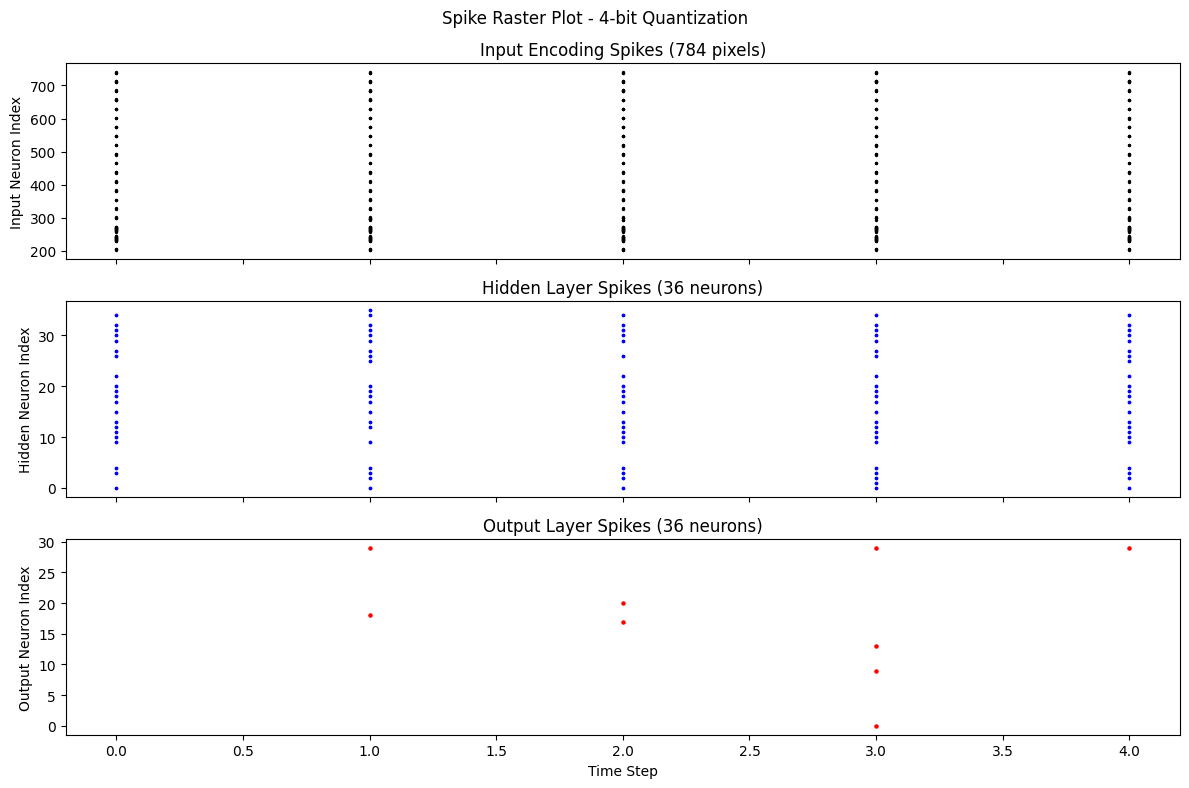


🔧 5-bit Quantization


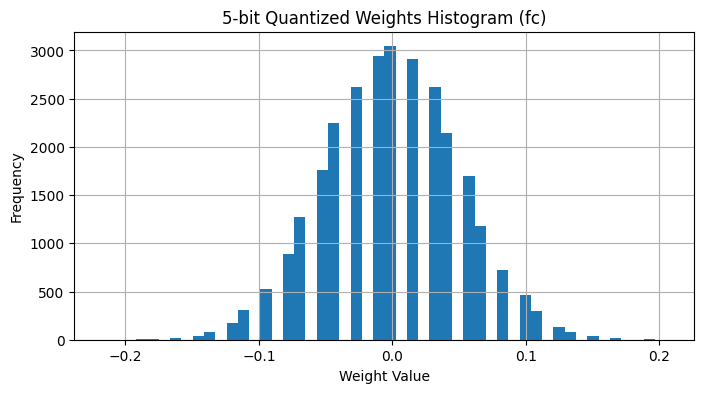

5-bit test accuracy: 26.29%


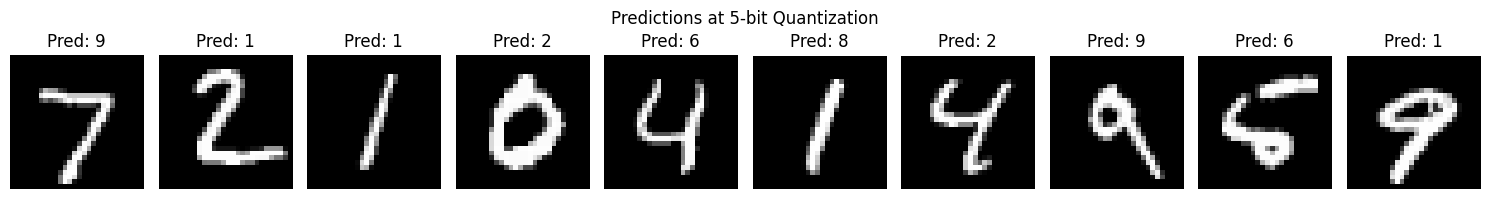

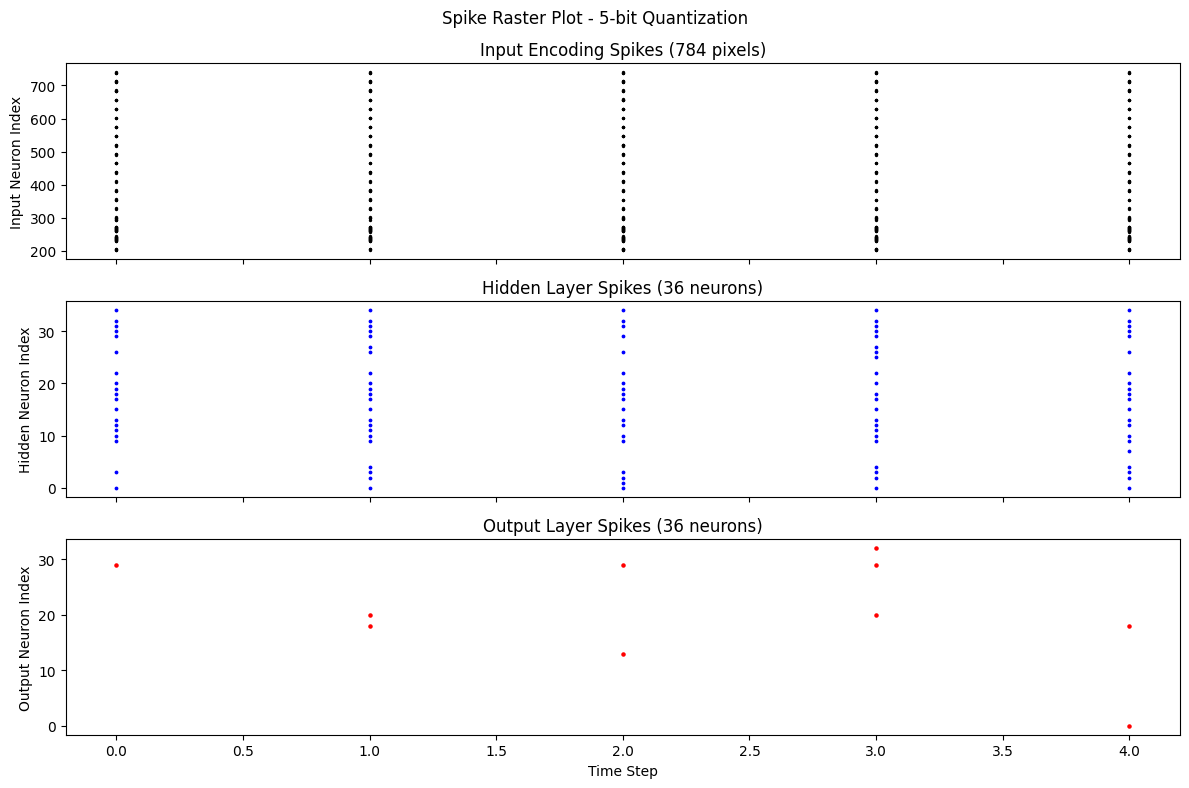

tensor([[-0.0563, -0.0576, -0.0125,  ..., -0.0791, -0.0294, -0.0057],
        [ 0.0351, -0.0278, -0.0191,  ...,  0.0199,  0.0129,  0.0100],
        [-0.0079,  0.0370, -0.0125,  ...,  0.0460, -0.0055, -0.0936],
        ...,
        [ 0.0133, -0.1272,  0.0331,  ...,  0.0215, -0.0051,  0.0018],
        [ 0.0799, -0.0117, -0.0501,  ..., -0.0619,  0.0270, -0.0187],
        [-0.0070, -0.0498, -0.0080,  ..., -0.0116,  0.0293,  0.0094]])

In [15]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from spikingjelly.activation_based import neuron, encoding, functional

# ========== Setup ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T = 5
lr = 1e-3
trace_decay = 0.9
num_neurons = 36

# ========== Load MNIST ==========
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_dataset = torchvision.datasets.MNIST('./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)
test_labels = test_labels.to(device)

# ========== STDPNet Architecture ==========
class STDPNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(28 * 28, num_neurons, bias=False)
        self.lif = neuron.LIFNode(v_threshold=0.5)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc(x)
        x = self.lif(x)
        return x

# Load pretrained STDPNet
model = STDPNet().to(device)
model.eval()

# Simulate previously trained weights
torch.manual_seed(0)
torch.nn.init.normal_(model.fc.weight, mean=0.0, std=0.05)
original_weights = model.fc.weight.data.clone()

# ========== Quantization Function ==========
def quantize_weights(w, bits):
    levels = 2 ** bits
    w_min = w.min()
    w_max = w.max()
    scale = (w_max - w_min) / (levels - 1)
    return torch.round((w - w_min) / scale) * scale + w_min

# Dummy label map: assign each neuron to the digit it fired most for
def build_neuron_label_map():
    neuron_activity = torch.zeros((num_neurons, 10))
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            functional.reset_net(model)
            outputs = torch.zeros((images.shape[0], num_neurons)).to(device)
            for t in range(T):
                outputs += model(encoder(images))
            winners = outputs.argmax(dim=1)
            for i in range(images.shape[0]):
                neuron_activity[winners[i], labels[i]] += 1
    return neuron_activity.argmax(dim=1)  # neuron_id -> digit

# ========== Spike Raster Plotting ==========
def plot_spike_raster(images, model, encoder, T, title="Spike Raster Plot"):
    model.eval()
    with torch.no_grad():
        functional.reset_net(model)
        input_spike_record = []
        hidden_spike_record = []
        output_spike_record = []

        for t in range(T):
            encoded = encoder(images)
            flat_encoded = encoded.view(encoded.shape[0], -1)
            input_spike_record.append((flat_encoded[0] > 0).float().cpu())

            hidden = model.fc(model.flatten(encoded))
            hidden_spike_record.append((hidden[0] > 0).float().cpu())

            output = model(encoded)
            output_spike_record.append((output > 0).float()[0].cpu())

    input_spikes = torch.stack(input_spike_record)  # [T, 784]
    hidden_spikes = torch.stack(hidden_spike_record)  # [T, num_neurons]
    output_spikes = torch.stack(output_spike_record)  # [T, num_neurons]

    fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axs[0].set_title("Input Encoding Spikes (784 pixels)")
    axs[1].set_title("Hidden Layer Spikes ({} neurons)".format(num_neurons))
    axs[2].set_title("Output Layer Spikes ({} neurons)".format(num_neurons))

    for t in range(T):
        axs[0].scatter([t] * input_spikes[t].sum().int().item(), torch.where(input_spikes[t] > 0)[0], s=2, color='black')
        axs[1].scatter([t] * hidden_spikes[t].sum().int().item(), torch.where(hidden_spikes[t] > 0)[0], s=3, color='blue')
        axs[2].scatter([t] * output_spikes[t].sum().int().item(), torch.where(output_spikes[t] > 0)[0], s=5, color='red')

    axs[2].set_xlabel("Time Step")
    axs[0].set_ylabel("Input Neuron Index")
    axs[1].set_ylabel("Hidden Neuron Index")
    axs[2].set_ylabel("Output Neuron Index")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# ========== Quantize and Evaluate ==========
bit_levels = [2, 3, 4, 5]
encoder = encoding.PoissonEncoder()

for bits in bit_levels:
    print(f"\n🔧 {bits}-bit Quantization")

    model.fc.weight.data.copy_(quantize_weights(original_weights, bits))

    # Histogram of quantized weights
    plt.figure(figsize=(8, 4))
    plt.hist(model.fc.weight.data.cpu().flatten(), bins=50)
    plt.title(f"{bits}-bit Quantized Weights Histogram (fc)")
    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    # Build neuron-to-digit label map
    neuron_label_map = build_neuron_label_map()

    # Evaluate accuracy
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            functional.reset_net(model)
            outputs = torch.zeros((images.shape[0], num_neurons)).to(device)
            for t in range(T):
                outputs += model(encoder(images))
            predicted_neurons = outputs.argmax(dim=1)
            predicted_digits = neuron_label_map[predicted_neurons]
            correct += (predicted_digits == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    print(f"{bits}-bit test accuracy: {acc:.2f}%")

    # Visualize response on test images
    with torch.no_grad():
        functional.reset_net(model)
        outputs = torch.zeros((test_images.shape[0], num_neurons)).to(device)
        for t in range(T):
            spikes = encoder(test_images)
            outputs += model(spikes)
        outputs /= T
        top_neurons = outputs.argmax(dim=1)
        pred_digits = neuron_label_map[top_neurons]

    # Plot images with predicted digit
    fig, axes = plt.subplots(1, 10, figsize=(15, 2))
    fig.suptitle(f"Predictions at {bits}-bit Quantization")
    for i, ax in enumerate(axes):
        ax.imshow(test_images[i].cpu().squeeze(), cmap='gray')
        ax.set_title(f"Pred: {pred_digits[i].item()}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Plot spike raster for 1 sample image
    plot_spike_raster(test_images[0:1], model, encoder, T, title=f"Spike Raster Plot - {bits}-bit Quantization")

# Restore original weights
model.fc.weight.data.copy_(original_weights)


SNN Accuracy Comparison:



*   Image Size 4x4: Accuracy 53.07%
*   Image Size 7x7: Accuracy 79.55%
*   Image Size 14x14: Accuracy 90.63%
*   Image Size 28x28: Accuracy 92.54%


*   Time Steps: T=5 -> Accuracy: 78.66%     
*   Time Steps: T=10 -> Accuracy: 91.34%  
*   Time Steps: T=20 -> Accuracy: 92.99%  

*   Training Method: Supervised -> Accuracy: 98.11%
*   Training Method: Unsupervised -> Accuracy: 38.48%

*   Quantization: 2-bit (supervised) -> Accuracy: 14.13%
*   Quantization: 3-bit (supervised) -> Accuracy: 96.57%
*   Quantization: 4-bit (supervised) -> Accuracy: 97.53%
*   Quantization: 5-bit (supervised) -> Accuracy: 97.55%

*   Quantization: 2-bit (unsupervised) -> Accuracy: 29.08%
*   Quantization: 3-bit (unsupervised) -> Accuracy: 24.46%
*   Quantization: 4-bit (unsupervised) -> Accuracy: 27.21%
*   Quantization: 5-bit (unsupervised) -> Accuracy: 26.29%
















Smaller Network:

In [16]:
class SmallSNN(nn.Module):
   def __init__(self):
       super().__init__()
       self.encoder = encoding.PoissonEncoder()
       self.fc1 = nn.Linear(28*28, 200)  # Reduced from 800 to 200
       self.sn1 = neuron.LIFNode()
       self.fc2 = nn.Linear(200, 10)
       self.sn2 = neuron.LIFNode()


   def forward(self, x, time_window=20):
       x = x.view(x.size(0), -1)
       out_spike = 0
       for t in range(time_window):
           encoded = self.encoder(x)
           out = self.fc1(encoded)
           out = self.sn1(out)
           out = self.fc2(out)
           out = self.sn2(out)
           out_spike += out
       return out_spike / time_window




Visualizing MNIST Images with Smaller Network:

🧠 Accuracy for 4x4 input (Small SNN): 52.29%


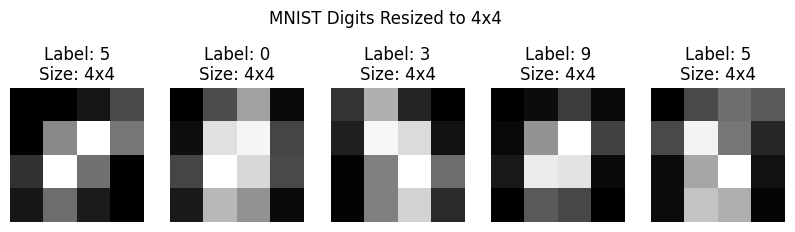

🧠 Accuracy for 7x7 input (Small SNN): 77.60%


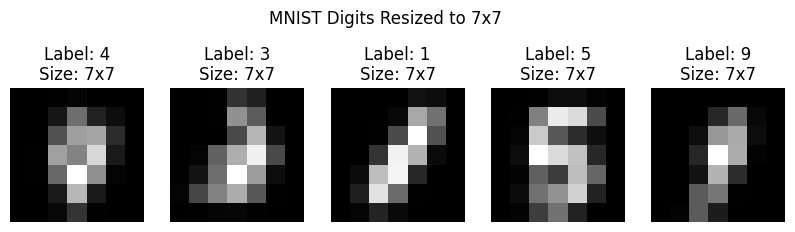

🧠 Accuracy for 14x14 input (Small SNN): 89.66%


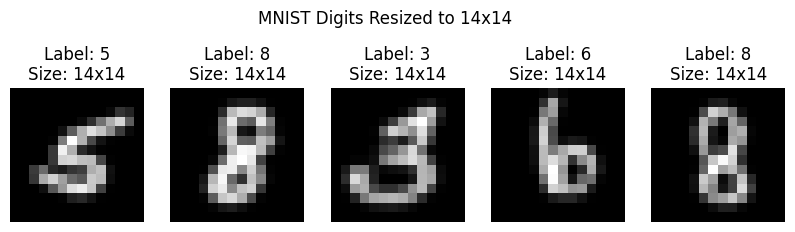

🧠 Accuracy for 28x28 input (Small SNN): 91.83%


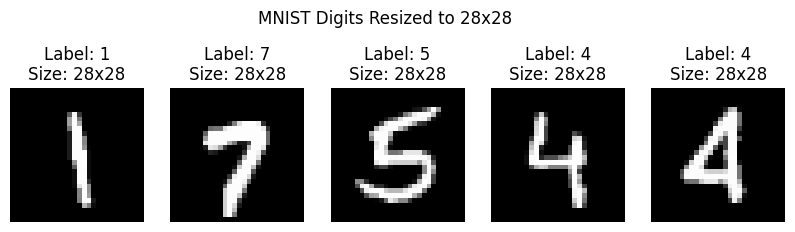

In [17]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from spikingjelly.activation_based import neuron, encoding, functional, surrogate

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T = 10  # time steps
epochs = 1
batch_size = 64
lr = 1e-3

resize_sizes = [(4, 4), (7, 7), (14, 14), (28, 28)]
train_loaders = {}
test_loaders = {}

# === Smaller SNN with fewer neurons ===
class SmallSNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, 64)  # Reduced hidden layer size
        self.lif1 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())
        self.fc2 = nn.Linear(64, 10)
        self.lif2 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.lif1(x)
        x = self.fc2(x)
        x = self.lif2(x)
        return x

# Loop through each size, train and evaluate
for size in resize_sizes:
    transform = transforms.Compose([
        transforms.Resize(size),
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    train_loaders[size] = train_loader
    test_loaders[size] = test_loader

    input_size = size[0] * size[1]
    model = SmallSNN(input_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    encoder = encoding.PoissonEncoder()

    # === Train ===
    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            functional.reset_net(model)
            out_spikes = 0
            for t in range(T):
                encoded = encoder(images)
                out_spikes += model(encoded)
            out_spikes /= T
            loss = criterion(out_spikes, labels)
            loss.backward()
            optimizer.step()

    # === Evaluate ===
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            functional.reset_net(model)
            out_spikes = 0
            for t in range(T):
                out_spikes += model(encoder(images))
            out_spikes /= T
            preds = out_spikes.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    print(f"🧠 Accuracy for {size[0]}x{size[1]} input (Small SNN): {acc:.2f}%")

    # === Visualize sample images ===
    data_iter = iter(train_loader)
    images, labels = next(data_iter)
    fig, axes = plt.subplots(1, 5, figsize=(10, 3))
    for i in range(5):
        axes[i].imshow(images[i].squeeze(), cmap='gray')
        axes[i].set_title(f"Label: {labels[i].item()}\nSize: {size[0]}x{size[1]}")
        axes[i].axis('off')
    plt.suptitle(f"MNIST Digits Resized to {size[0]}x{size[1]}")
    plt.show()


Poisson Encoding with Smaller SNN:

In [18]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch import nn
from torch.utils.data import DataLoader
from spikingjelly.activation_based import neuron, encoding, functional
import matplotlib.pyplot as plt


# ==== Configuration ====
resize_size = (14, 14)  # You can change this to (4,4), (7,7), (28,28)
input_size = resize_size[0] * resize_size[1]
batch_size = 64
epochs = 1
time_steps_list = [5, 10, 20]


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ==== Data Preparation ====
transform = transforms.Compose([
   transforms.Resize(resize_size),
   transforms.ToTensor(),
   transforms.Normalize((0.1307,), (0.3081,))
])


train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


# ==== Define Smaller SNN Model ====
class SmallSNN(nn.Module):
   def __init__(self, input_size):
       super().__init__()
       self.flatten = nn.Flatten()
       self.fc1 = nn.Linear(input_size, 128)
       self.sn1 = neuron.LIFNode()
       self.fc2 = nn.Linear(128, 10)
       self.sn2 = neuron.LIFNode()


   def forward(self, x):
       x = self.flatten(x)
       x = self.fc1(x)
       x = self.sn1(x)
       x = self.fc2(x)
       x = self.sn2(x)
       return x


# ==== Training Function ====
def train_snn(model, train_loader, T=10, device='cpu', epochs=1):
   model.train()
   encoder = encoding.PoissonEncoder()
   optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
   loss_fn = nn.CrossEntropyLoss()


   for epoch in range(epochs):
       total_loss = 0
       correct = 0
       total = 0


       for images, labels in train_loader:
           images = images.to(device)
           labels = labels.to(device)


           optimizer.zero_grad()
           outputs = 0


           functional.reset_net(model)  # Reset neuron states


           for t in range(T):
               encoded = encoder(images)
               out = model(encoded)
               outputs += out


           outputs /= T
           loss = loss_fn(outputs, labels)
           loss.backward()
           optimizer.step()


           total_loss += loss.item()
           pred = outputs.argmax(dim=1)
           correct += (pred == labels).sum().item()
           total += labels.size(0)


       print(f"Epoch {epoch+1}, Time Steps = {T}: Loss = {total_loss:.4f}, Accuracy = {100. * correct / total:.2f}%")


# ==== Run Training with Different Time Steps ====
for T in time_steps_list:
   print(f"\n=== Training with T = {T} time steps ===")
   model = SmallSNN(input_size=input_size).to(device)
   train_snn(model, train_loader, T=T, device=device, epochs=epochs)



=== Training with T = 5 time steps ===
Epoch 1, Time Steps = 5: Loss = 1562.4610, Accuracy = 79.28%

=== Training with T = 10 time steps ===
Epoch 1, Time Steps = 10: Loss = 1560.4101, Accuracy = 80.94%

=== Training with T = 20 time steps ===
Epoch 1, Time Steps = 20: Loss = 1560.1710, Accuracy = 81.07%


Visualizing MNIST Images With Different Time Steps for Smaller SNN:

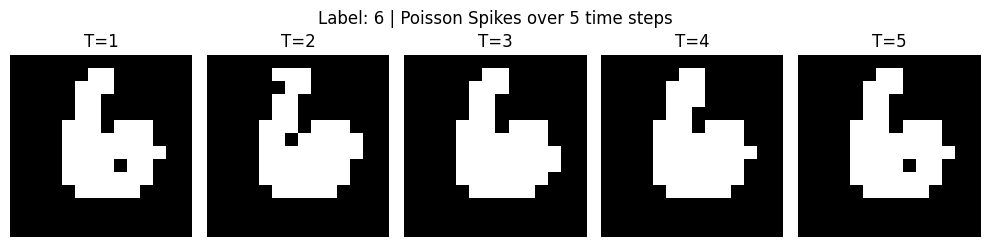

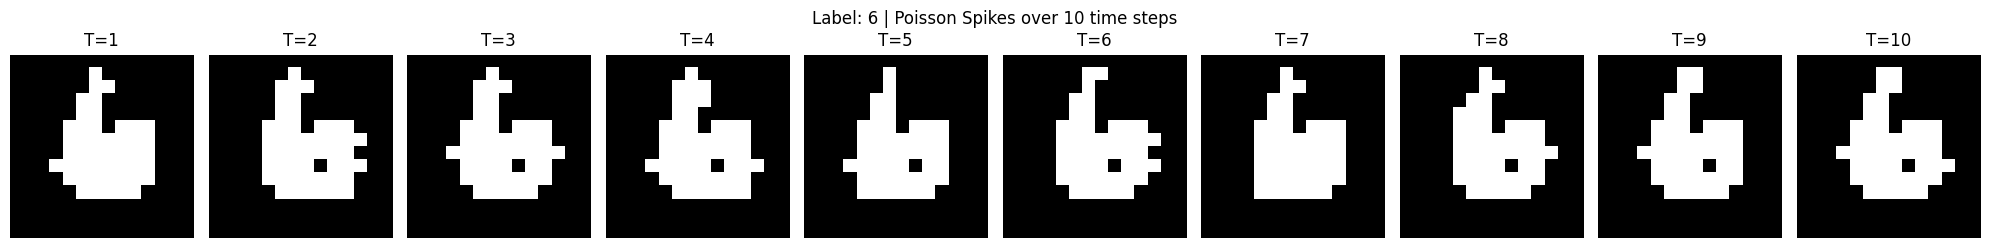

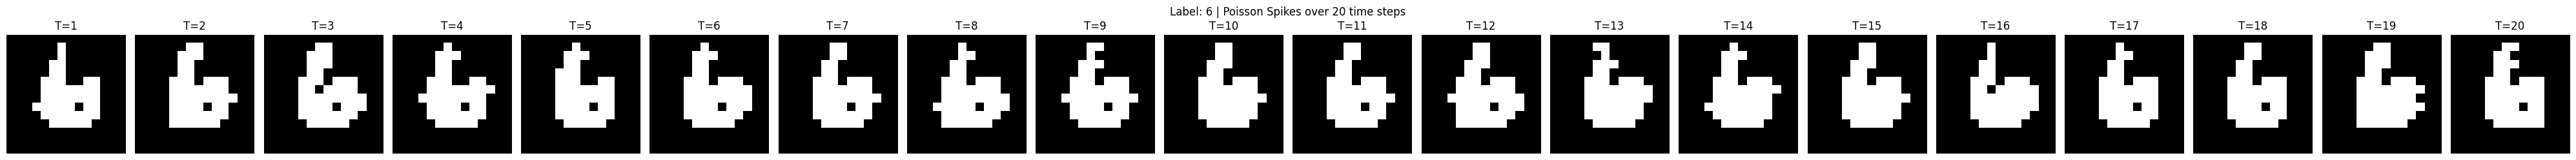

In [19]:
import matplotlib.pyplot as plt
from spikingjelly.activation_based import encoding
import torch


# Get a batch from the resized 14x14 train_loader
images, labels = next(iter(train_loader))  # Already resized to 14x14 via transform
image = images[0]  # shape: [1, 14, 14]
label = labels[0]


encoder = encoding.PoissonEncoder()
T_values = [5, 10, 20]


# Loop through each T and plot the spike maps
for T in T_values:
   fig, axes = plt.subplots(1, T, figsize=(T*2, 2.5))
   fig.suptitle(f"Label: {label.item()} | Poisson Spikes over {T} time steps", fontsize=12)


   for t in range(T):
       spike = encoder(image.unsqueeze(0))  # shape: [1, 1, 14, 14]
       spike_image = spike.squeeze().cpu().numpy()  # shape: [14, 14]
       axes[t].imshow(spike_image, cmap='gray')
       axes[t].set_title(f"T={t+1}")
       axes[t].axis('off')


   plt.tight_layout()
   plt.show()


Visualizing the Poisson Spikes (Raster Plot) for Smaller SNN:

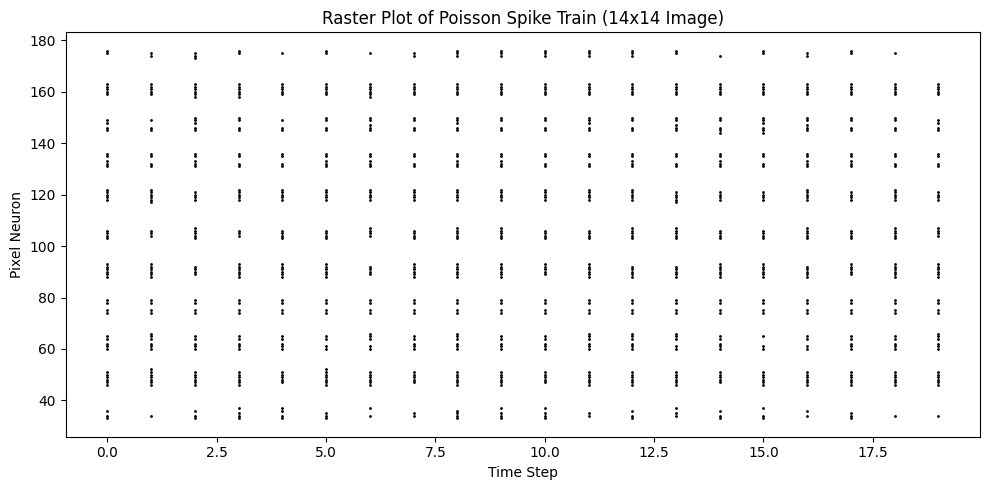

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from spikingjelly.activation_based import encoding


# Load one sample image from resized 14x14 dataset
example_img, _ = next(iter(train_loader))
example_img = example_img[0]  # Take the first image in batch, shape: [1, 14, 14]
T = 20  # Number of time steps


# Initialize Poisson encoder
encoder = encoding.PoissonEncoder()


# Encode the image across T time steps
spike_trains = []
for t in range(T):
   spikes = encoder(example_img.unsqueeze(0))  # shape: [1, 1, 14, 14]
   spike_trains.append(spikes.squeeze().numpy())  # shape: [14, 14]


# Convert to NumPy array: shape = (T, H, W)
spike_array = np.array(spike_trains)


# Flatten spatial dimensions for raster plot: (pixels, T)
H, W = example_img.shape[1], example_img.shape[2]  # 14 x 14
spike_array_flat = spike_array.reshape(T, H * W).T  # shape: (196, T)


# Plot raster
plt.figure(figsize=(10, 5))
for neuron_id, spikes in enumerate(spike_array_flat):
   times = np.where(spikes > 0)[0]
   plt.scatter(times, [neuron_id] * len(times), s=1, color='black')


plt.xlabel("Time Step")
plt.ylabel("Pixel Neuron")
plt.title("Raster Plot of Poisson Spike Train (14x14 Image)")
plt.tight_layout()
plt.show()


Supervised Learning for Smaller SNN: Surrogate Gradient Descent

Epoch 1 | Loss: 1560.6511 | Accuracy: 81.38%
Epoch 2 | Loss: 1450.7068 | Accuracy: 91.61%
Epoch 3 | Loss: 1437.0969 | Accuracy: 92.88%
Epoch 4 | Loss: 1429.3519 | Accuracy: 93.74%
Epoch 5 | Loss: 1423.8996 | Accuracy: 94.31%


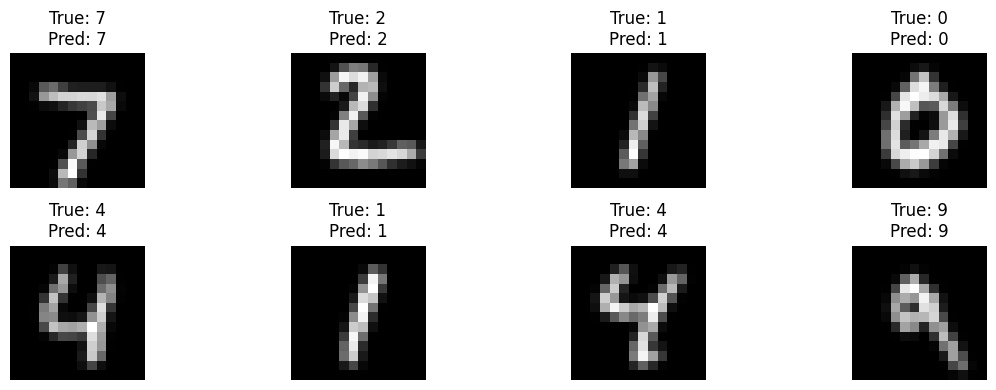

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np


from spikingjelly.activation_based import neuron, functional, encoding, surrogate


# ========== Setup ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 5
T = 20
batch_size = 64
lr = 1e-3
resize = (14, 14)
input_size = resize[0] * resize[1]


# ========== Load Resized MNIST ==========
transform = transforms.Compose([
   transforms.Resize(resize),
   transforms.ToTensor(),
   transforms.Normalize((0.1307,), (0.3081,))
])


train_loader = torch.utils.data.DataLoader(
   torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform),
   batch_size=batch_size,
   shuffle=True
)


test_loader = torch.utils.data.DataLoader(
   torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform),
   batch_size=batch_size,
   shuffle=False
)


# ========== Define Smaller SNN ==========
class SmallSNN(nn.Module):
   def __init__(self, input_size):
       super().__init__()
       self.flatten = nn.Flatten()
       self.fc1 = nn.Linear(input_size, 128)
       self.lif1 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())
       self.fc2 = nn.Linear(128, 10)
       self.lif2 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())


   def forward(self, x):
       x = self.flatten(x)
       x = self.fc1(x)
       x = self.lif1(x)
       x = self.fc2(x)
       x = self.lif2(x)
       return x


model = SmallSNN(input_size).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()
encoder = encoding.PoissonEncoder()


# ========== Training ==========
for epoch in range(epochs):
   model.train()
   total_loss = 0
   correct = 0
   total = 0


   for images, labels in train_loader:
       images = images.to(device)
       labels = labels.to(device)


       functional.reset_net(model)
       optimizer.zero_grad()


       out_spikes = 0
       for t in range(T):
           spikes = encoder(images)
           out_spikes += model(spikes)
       out_spikes /= T


       loss = loss_fn(out_spikes, labels)
       loss.backward()
       optimizer.step()


       total_loss += loss.item()
       pred = out_spikes.argmax(dim=1)
       correct += (pred == labels).sum().item()
       total += labels.size(0)


   acc = 100 * correct / total
   print(f"Epoch {epoch+1} | Loss: {total_loss:.4f} | Accuracy: {acc:.2f}%")


# ========== Visualization ==========
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)


functional.reset_net(model)
out_spikes = 0
for t in range(T):
   spikes = encoder(images)
   out_spikes += model(spikes)
out_spikes /= T


preds = out_spikes.argmax(dim=1)


plt.figure(figsize=(12, 4))
for i in range(8):
   plt.subplot(2, 4, i+1)
   plt.imshow(images[i].cpu().squeeze(), cmap='gray')
   plt.title(f"True: {labels[i].item()}\nPred: {preds[i].item()}")
   plt.axis('off')
plt.tight_layout()
plt.show()




Unsupervised Training for Smaller SNN: Full Minimal STDP Training Code


🧠 Starting STDP training...
Epoch 1 complete
Epoch 2 complete
Epoch 3 complete
Epoch 4 complete
Epoch 5 complete
✅ STDP training finished!


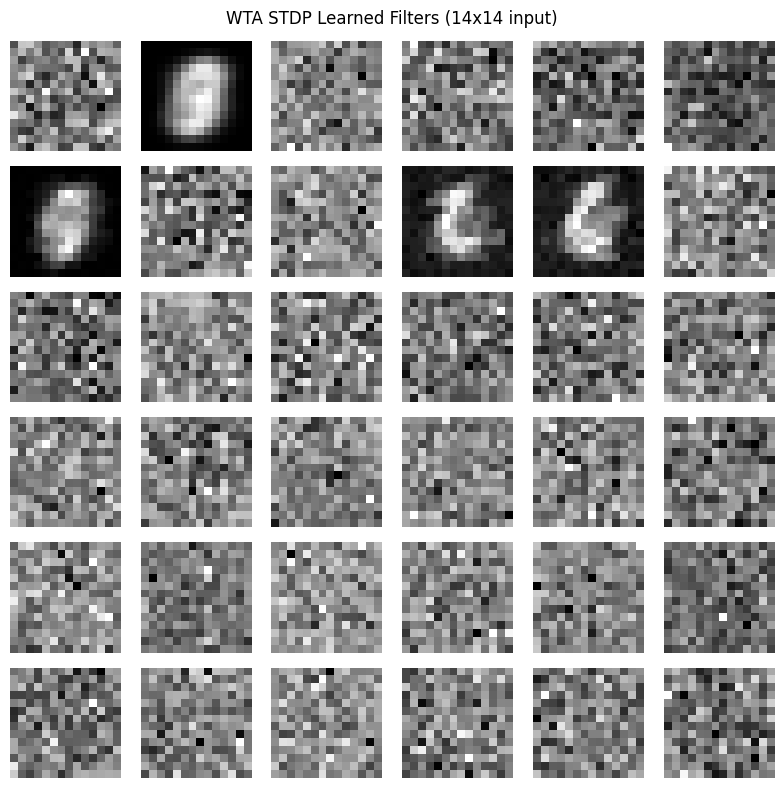


🔁 Training classifier on frozen STDP features...
Epoch 1: Accuracy=9.65%
Epoch 2: Accuracy=18.95%
Epoch 3: Accuracy=26.75%
Epoch 4: Accuracy=33.70%
Epoch 5: Accuracy=42.55%

✅ Final Test Accuracy using STDP features: 44.08%


In [22]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from spikingjelly.activation_based import neuron, encoding, functional


# ========== Hyperparameters ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T = 5
lr = 1e-3
epochs = 5
num_neurons = 36
trace_decay = 0.9
resize = (14, 14)
input_size = resize[0] * resize[1]


# ========== Load Resized MNIST Subset ==========
transform = transforms.Compose([
   transforms.Resize(resize),
   transforms.ToTensor(),
   transforms.Normalize((0.1307,), (0.3081,))
])


full_dataset = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform)
subset = Subset(full_dataset, range(2000))  # use small subset for speed
train_loader = DataLoader(subset, batch_size=64, shuffle=True)


test_dataset = torchvision.datasets.MNIST('./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


# ========== Define Smaller STDPNet ==========
class STDPNet(nn.Module):
   def __init__(self):
       super().__init__()
       self.flatten = nn.Flatten()
       self.fc = nn.Linear(input_size, num_neurons, bias=False)
       self.lif = neuron.LIFNode(v_threshold=0.5)


   def forward(self, x):
       x = self.flatten(x)
       x = self.fc(x)
       x = self.lif(x)
       return x


model = STDPNet().to(device)
torch.nn.init.normal_(model.fc.weight, mean=0.0, std=0.01)


encoder = encoding.PoissonEncoder()
pre_trace = torch.zeros_like(model.fc.weight.data)


# ========== STDP Update Rule ==========
def stdp_update(pre_spike, post_spike):
   global pre_trace
   pre_trace = trace_decay * pre_trace + pre_spike


   if post_spike.sum() > 0:
       winner = torch.argmax(post_spike)
       post_spike[:] = 0
       post_spike[0, winner] = 1


       dw = torch.einsum('bi,bj->ij', post_spike, pre_trace)
       model.fc.weight.data += lr * dw


# ========== Unsupervised STDP Training ==========
print("\n🧠 Starting STDP training...")
for epoch in range(epochs):
   for images, _ in train_loader:
       images = images.to(device)


       for i in range(images.size(0)):
           functional.reset_net(model)
           for t in range(T):
               spikes = encoder(images[i].unsqueeze(0))  # shape: [1, 1, 14, 14]
               pre_spike = spikes.view(1, -1).float()
               out = model(spikes)
               post_spike = (out > 0).float()
               stdp_update(pre_spike, post_spike)


   with torch.no_grad():
       model.fc.weight.data = torch.nn.functional.normalize(model.fc.weight.data, p=2, dim=1)


   print(f"Epoch {epoch + 1} complete")


print("✅ STDP training finished!")


# ========== Visualize Learned Filters ==========
with torch.no_grad():
   weights = model.fc.weight.data.cpu().numpy()
   fig, axes = plt.subplots(6, 6, figsize=(8, 8))
   for i, ax in enumerate(axes.flat):
       ax.imshow(weights[i].reshape(resize), cmap='gray')
       ax.axis('off')
   plt.suptitle("WTA STDP Learned Filters (14x14 input)")
   plt.tight_layout()
   plt.show()


# ========== Train Classifier on STDP Features ==========
class ClassifierNet(nn.Module):
   def __init__(self, feature_extractor):
       super().__init__()
       self.feature_extractor = feature_extractor
       self.classifier = nn.Linear(num_neurons, 10)


   def forward(self, x):
       with torch.no_grad():
           x = self.feature_extractor.flatten(x)
           x = self.feature_extractor.fc(x)
           x = torch.relu(x)
       return self.classifier(x)


clf_model = ClassifierNet(model).to(device)
optimizer = torch.optim.Adam(clf_model.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()


print("\n🔁 Training classifier on frozen STDP features...")
for epoch in range(5):
   clf_model.train()
   total = correct = 0
   for images, labels in train_loader:
       images, labels = images.to(device), labels.to(device)
       output = clf_model(images)
       loss = criterion(output, labels)
       optimizer.zero_grad()
       loss.backward()
       optimizer.step()


       preds = output.argmax(dim=1)
       correct += (preds == labels).sum().item()
       total += labels.size(0)


   print(f"Epoch {epoch + 1}: Accuracy={100 * correct / total:.2f}%")


# ========== Final Evaluation ==========
clf_model.eval()
correct = total = 0
with torch.no_grad():
   for images, labels in test_loader:
       images, labels = images.to(device), labels.to(device)
       output = clf_model(images)
       preds = output.argmax(dim=1)
       correct += (preds == labels).sum().item()
       total += labels.size(0)


print(f"\n✅ Final Test Accuracy using STDP features: {100 * correct / total:.2f}%")


Quantizing the Weights for Smaller SNN (Using supervised SNN model): Including raster plots to visualize the spiking behavior of the network


🧠 Training supervised SNN...
Epoch 1: Loss=1558.8240, Accuracy=81.29%
Epoch 2: Loss=1450.8718, Accuracy=91.59%
Epoch 3: Loss=1436.8390, Accuracy=92.91%
Epoch 4: Loss=1428.9285, Accuracy=93.76%
Epoch 5: Loss=1423.6701, Accuracy=94.37%

✅ Full-precision test accuracy: 94.75%

🔍 Quantization Results:
2-bit accuracy: 17.76%


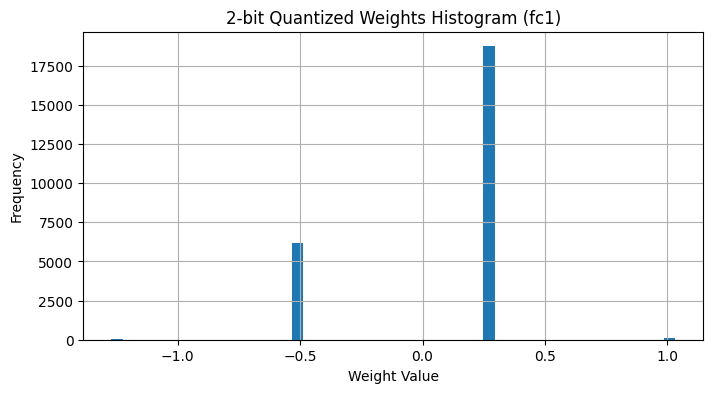

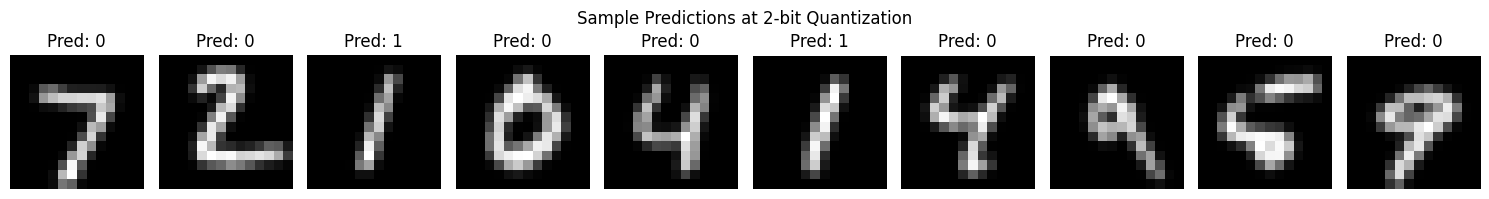

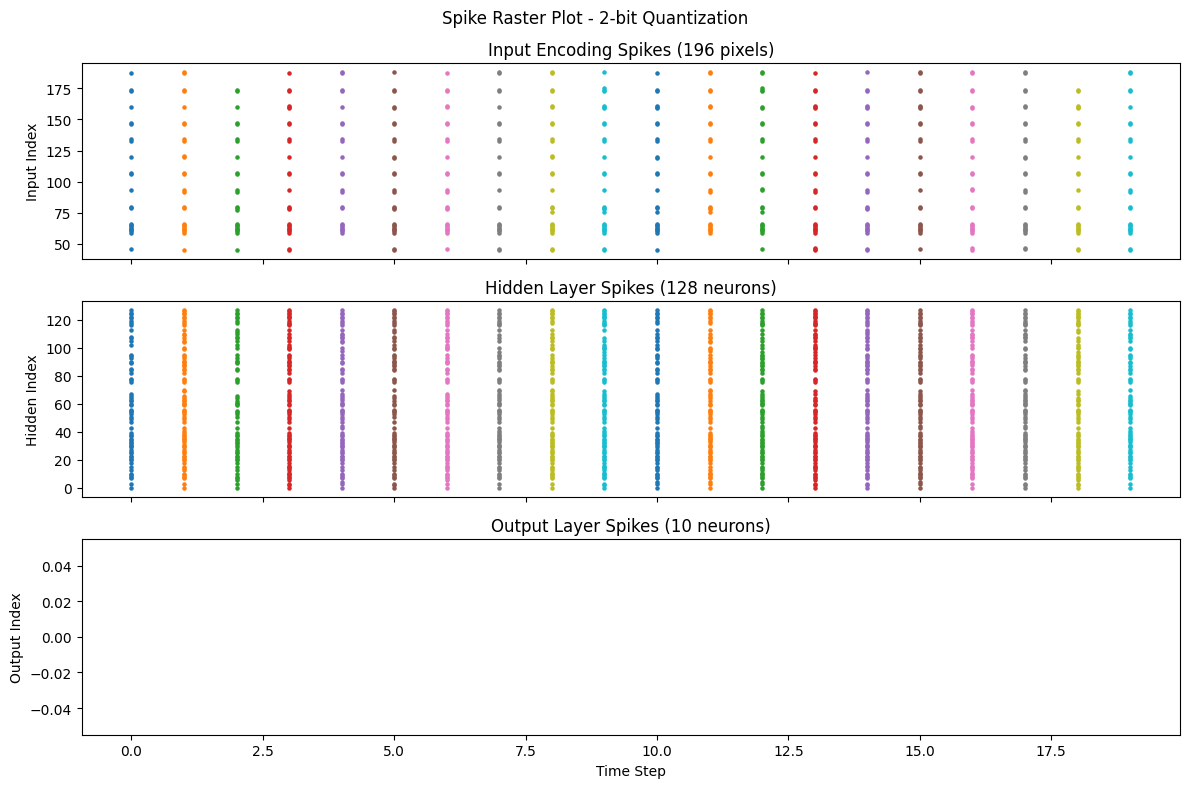

3-bit accuracy: 94.06%


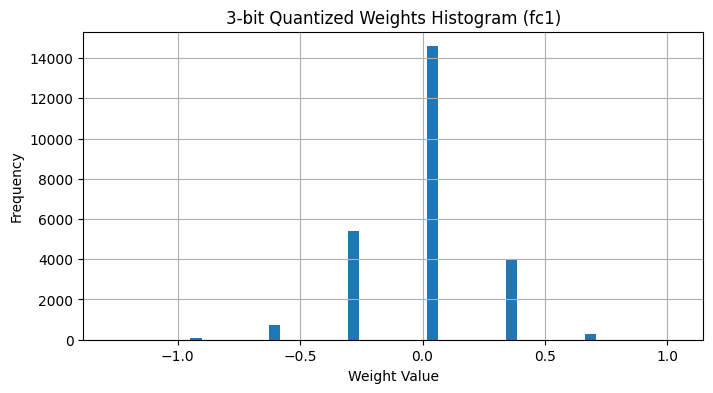

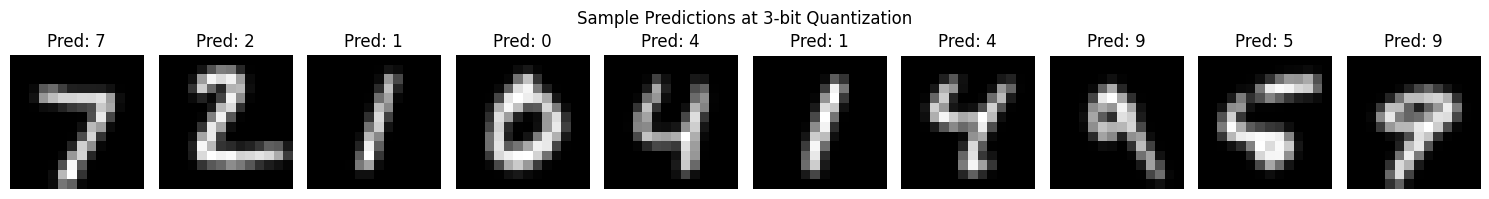

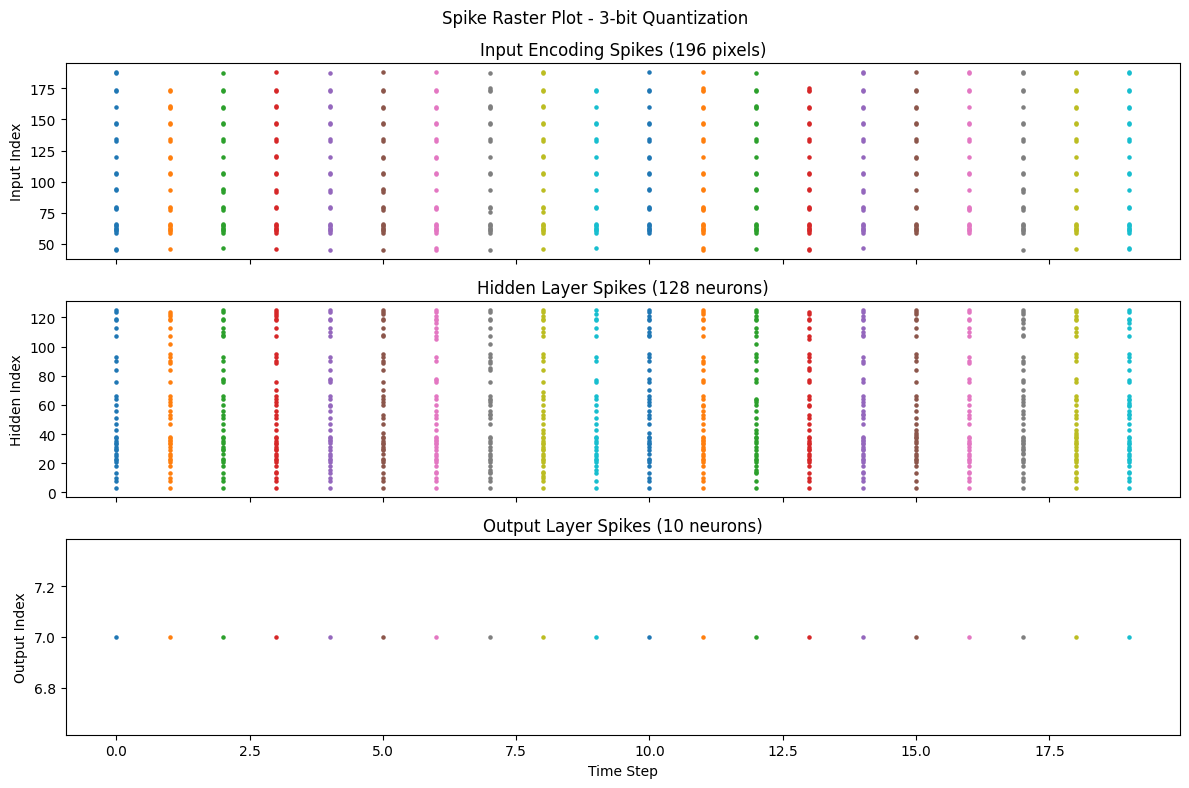

4-bit accuracy: 94.64%


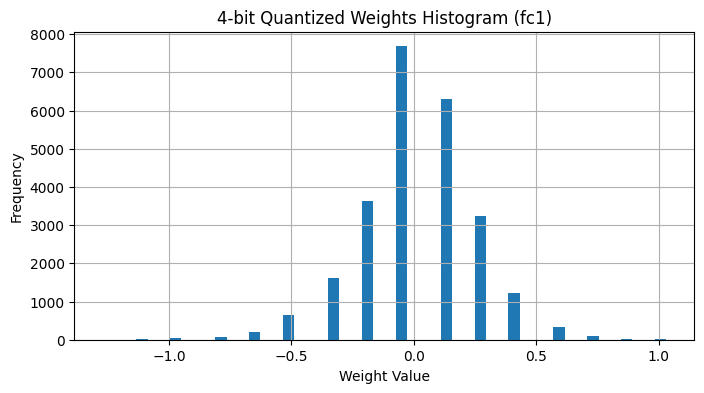

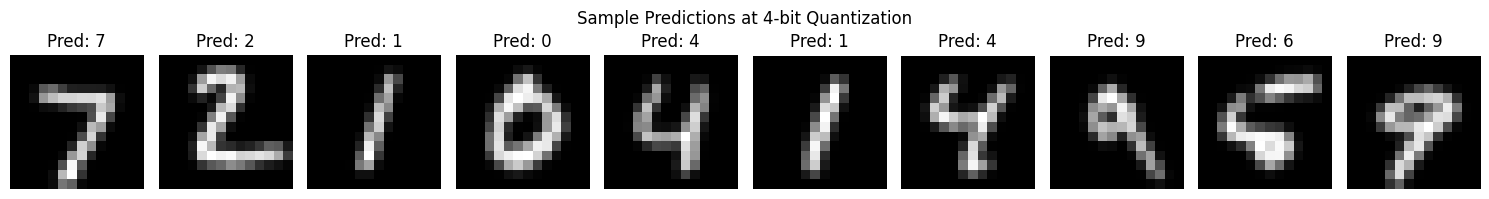

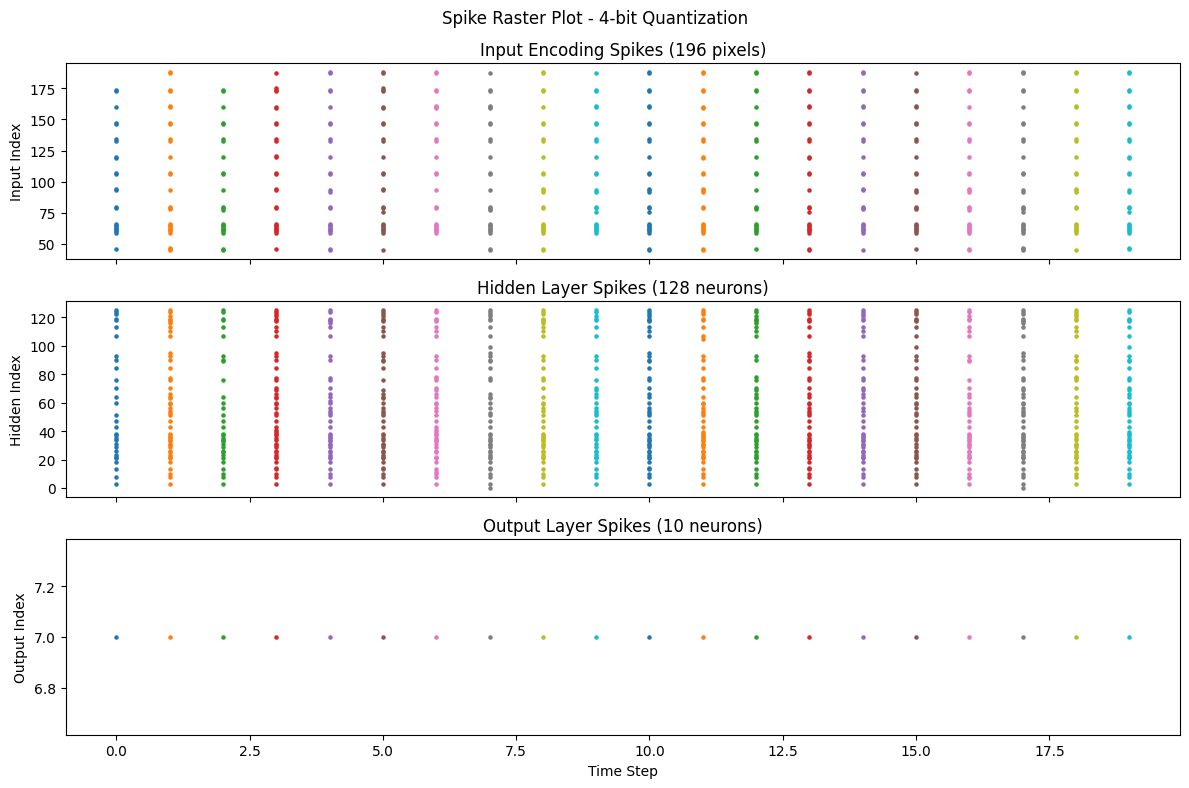

5-bit accuracy: 94.69%


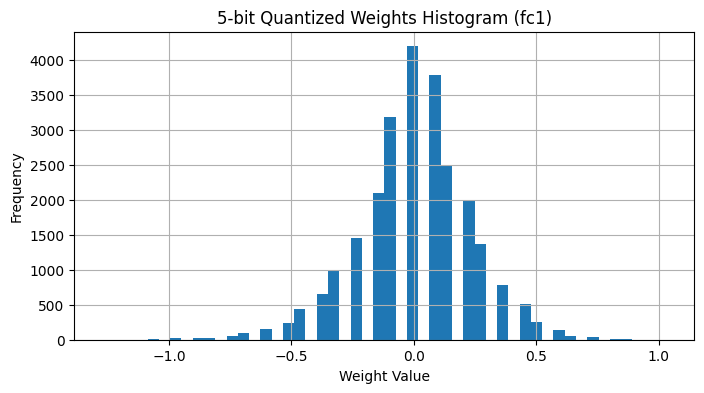

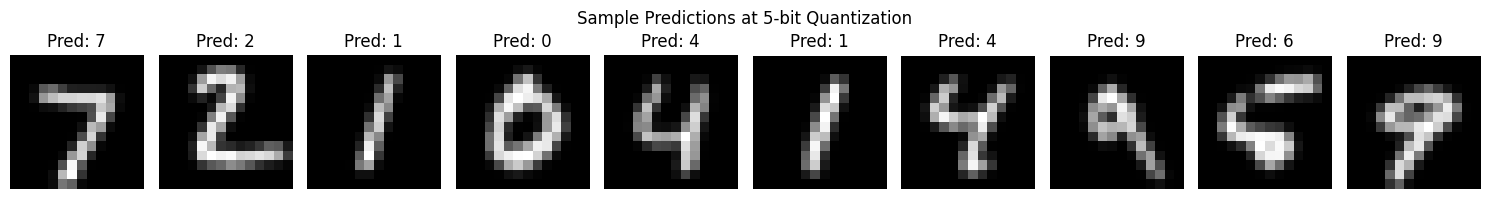

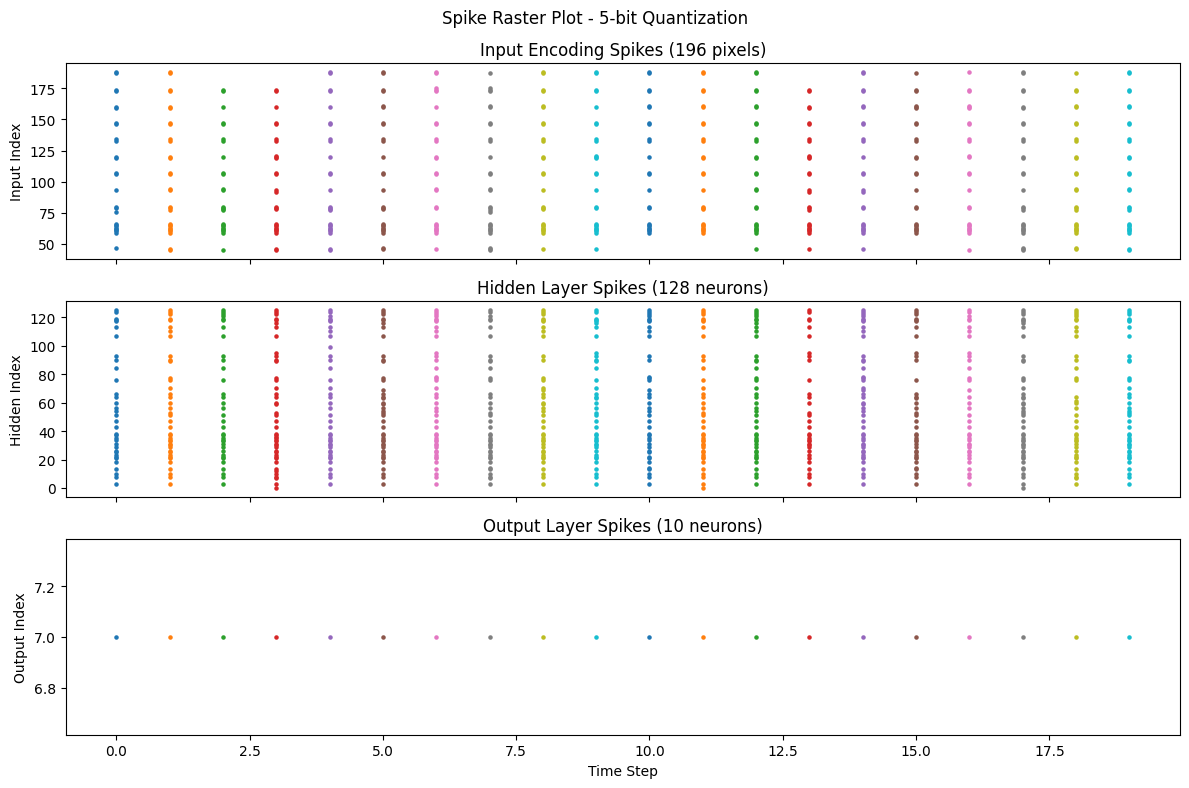

tensor([[-0.7769, -0.4441,  0.1064,  ..., -1.3000,  0.2912, -0.3234],
        [-0.4725, -0.5928,  0.2428,  ..., -0.6081, -0.9220, -1.3394],
        [-0.7245,  0.2086,  0.3618,  ..., -0.9885, -0.3273, -0.5255],
        ...,
        [-0.7796, -0.3608, -0.1556,  ...,  0.2370, -0.2831, -1.1957],
        [-1.2304, -1.1212,  0.1004,  ..., -0.3671,  0.1357,  0.1114],
        [ 0.2669, -0.9290, -0.3497,  ...,  0.3557, -0.3442, -0.5611]])

In [23]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


from torch.utils.data import DataLoader
from spikingjelly.activation_based import neuron, encoding, functional, surrogate


# ========== Setup ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T = 20
epochs = 5
batch_size = 64
lr = 1e-3
resize = (14, 14)
input_size = resize[0] * resize[1]
hidden_neurons = 128


# ========== Load 14x14 MNIST ==========
transform = transforms.Compose([
   transforms.Resize(resize),
   transforms.ToTensor(),
   transforms.Normalize((0.1307,), (0.3081,))
])


train_dataset = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform)


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# ========== Smaller Supervised SNN ==========
class SmallSNN(nn.Module):
   def __init__(self):
       super().__init__()
       self.flatten = nn.Flatten()
       self.fc1 = nn.Linear(input_size, hidden_neurons)
       self.lif1 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())
       self.fc2 = nn.Linear(hidden_neurons, 10)
       self.lif2 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())


   def forward(self, x):
       x = self.flatten(x)
       x = self.fc1(x)
       x = self.lif1(x)
       x = self.fc2(x)
       x = self.lif2(x)
       return x


model = SmallSNN().to(device)
encoder = encoding.PoissonEncoder()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()


# ========== Train the Model ==========
print("\n🧠 Training supervised SNN...")
for epoch in range(epochs):
   model.train()
   total_loss = 0
   correct = 0
   total = 0
   for images, labels in train_loader:
       images, labels = images.to(device), labels.to(device)
       optimizer.zero_grad()
       functional.reset_net(model)
       out_spikes = 0
       for t in range(T):
           out_spikes += model(encoder(images))
       out_spikes /= T
       loss = criterion(out_spikes, labels)
       loss.backward()
       optimizer.step()


       total_loss += loss.item()
       pred = out_spikes.argmax(dim=1)
       correct += (pred == labels).sum().item()
       total += labels.size(0)


   print(f"Epoch {epoch+1}: Loss={total_loss:.4f}, Accuracy={100 * correct / total:.2f}%")


# ========== Baseline Accuracy ==========
model.eval()
correct = 0
total = 0
with torch.no_grad():
   for images, labels in test_loader:
       images, labels = images.to(device), labels.to(device)
       functional.reset_net(model)
       out_spikes = 0
       for t in range(T):
           out_spikes += model(encoder(images))
       out_spikes /= T
       preds = out_spikes.argmax(dim=1)
       correct += (preds == labels).sum().item()
       total += labels.size(0)


baseline_acc = 100 * correct / total
print(f"\n✅ Full-precision test accuracy: {baseline_acc:.2f}%")


# ========== Quantization Function ==========
def quantize_weights(w, bits):
   levels = 2 ** bits
   w_min = w.min()
   w_max = w.max()
   scale = (w_max - w_min) / (levels - 1)
   return torch.round((w - w_min) / scale) * scale + w_min


# Save original weights
original_fc1 = model.fc1.weight.data.clone()
original_fc2 = model.fc2.weight.data.clone()


test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)


# ========== Spike Raster Plot Function ==========
def plot_supervised_spike_raster(images, model, encoder, T, title="Spike Raster Plot"):
   model.eval()
   with torch.no_grad():
       functional.reset_net(model)
       input_record = []
       hidden_record = []
       output_record = []


       for t in range(T):
           encoded = encoder(images)
           flat = model.flatten(encoded)
           hidden = model.lif1(model.fc1(flat))
           output = model.lif2(model.fc2(hidden))


           input_record.append(flat[0].cpu())
           hidden_record.append(hidden[0].cpu())
           output_record.append(output[0].cpu())


   fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
   axs[0].set_title(f"Input Encoding Spikes ({input_size} pixels)")
   axs[1].set_title(f"Hidden Layer Spikes ({hidden_neurons} neurons)")
   axs[2].set_title("Output Layer Spikes (10 neurons)")


   for t in range(T):
       for ax, record in zip(axs, [input_record, hidden_record, output_record]):
           y = torch.where(record[t] > 0)[0].numpy()
           x = [t] * len(y)
           ax.scatter(x, y, s=5)


   axs[2].set_xlabel("Time Step")
   axs[0].set_ylabel("Input Index")
   axs[1].set_ylabel("Hidden Index")
   axs[2].set_ylabel("Output Index")
   plt.suptitle(title)
   plt.tight_layout()
   plt.show()


# ========== Quantize and Evaluate ==========
bit_levels = [2, 3, 4, 5]
print("\n🔍 Quantization Results:")
for bits in bit_levels:
   # Quantize
   model.fc1.weight.data.copy_(quantize_weights(original_fc1, bits))
   model.fc2.weight.data.copy_(quantize_weights(original_fc2, bits))


   # Evaluate accuracy
   model.eval()
   correct = 0
   total = 0
   with torch.no_grad():
       for images, labels in test_loader:
           images, labels = images.to(device), labels.to(device)
           functional.reset_net(model)
           out_spikes = 0
           for t in range(T):
               out_spikes += model(encoder(images))
           out_spikes /= T
           preds = out_spikes.argmax(dim=1)
           correct += (preds == labels).sum().item()
           total += labels.size(0)


   acc = 100 * correct / total
   print(f"{bits}-bit accuracy: {acc:.2f}%")


   # Plot weight histogram
   plt.figure(figsize=(8, 4))
   plt.hist(model.fc1.weight.data.cpu().flatten(), bins=50)
   plt.title(f"{bits}-bit Quantized Weights Histogram (fc1)")
   plt.xlabel("Weight Value")
   plt.ylabel("Frequency")
   plt.grid(True)
   plt.show()


   # Visualize predictions
   with torch.no_grad():
       functional.reset_net(model)
       out_spikes = 0
       for t in range(T):
           out_spikes += model(encoder(test_images))
       out_spikes /= T
       preds = out_spikes.argmax(dim=1)


   fig, axes = plt.subplots(1, 10, figsize=(15, 2))
   fig.suptitle(f"Sample Predictions at {bits}-bit Quantization")
   for i, ax in enumerate(axes):
       ax.imshow(test_images[i].cpu().squeeze(), cmap='gray')
       ax.set_title(f"Pred: {preds[i].item()}")
       ax.axis('off')
   plt.tight_layout()
   plt.show()


   # Spike raster plot
   plot_supervised_spike_raster(test_images[0:1], model, encoder, T, title=f"Spike Raster Plot - {bits}-bit Quantization")


# ========== Restore Original Weights ==========
model.fc1.weight.data.copy_(original_fc1)
model.fc2.weight.data.copy_(original_fc2)


Quantizing the Weights for Smaller SNN (Using unsupervised SNN model): Including raster plots to visualize the spiking behavior of the network


🔧 2-bit Quantization


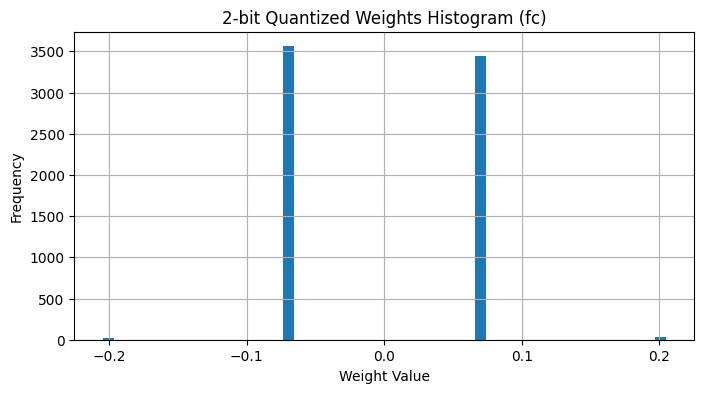

2-bit test accuracy: 24.99%


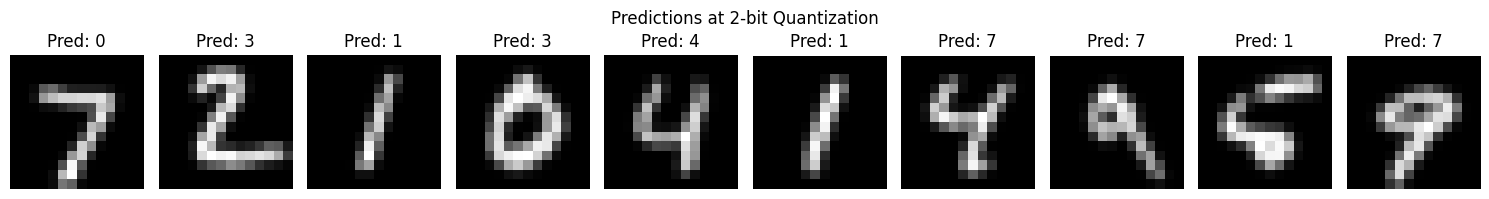

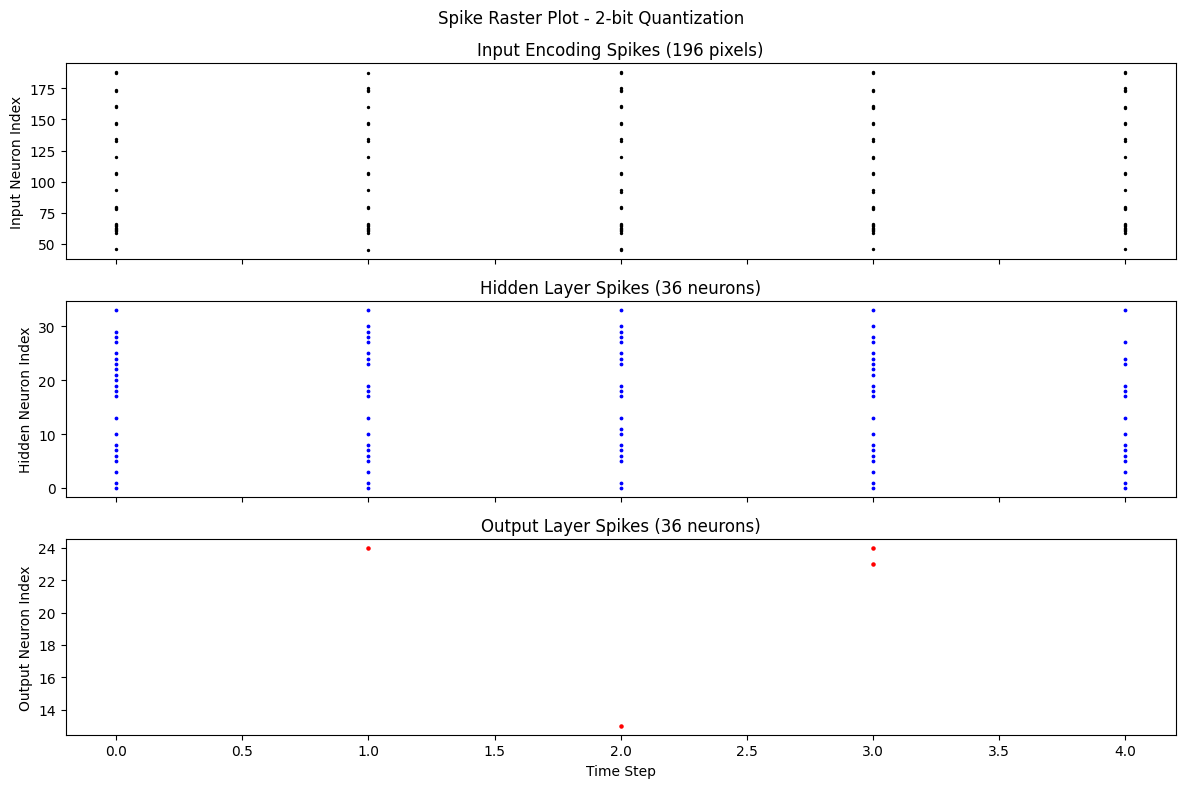


🔧 3-bit Quantization


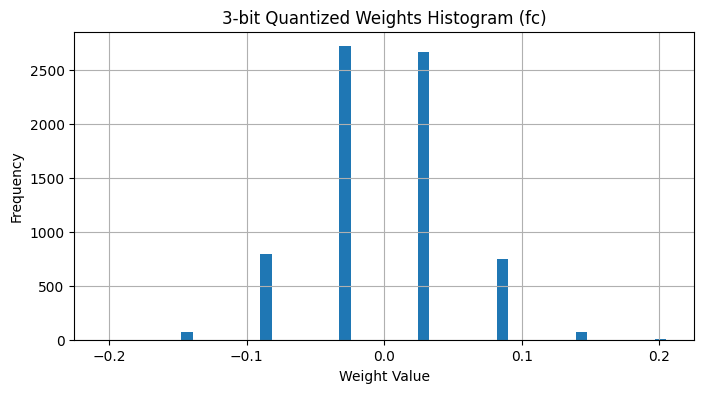

3-bit test accuracy: 25.12%


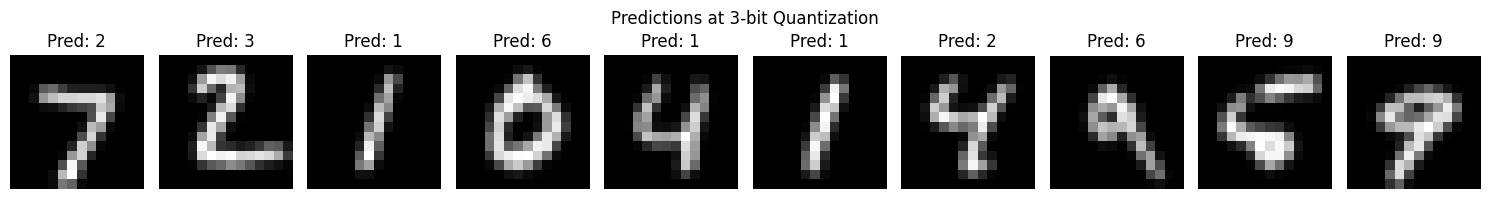

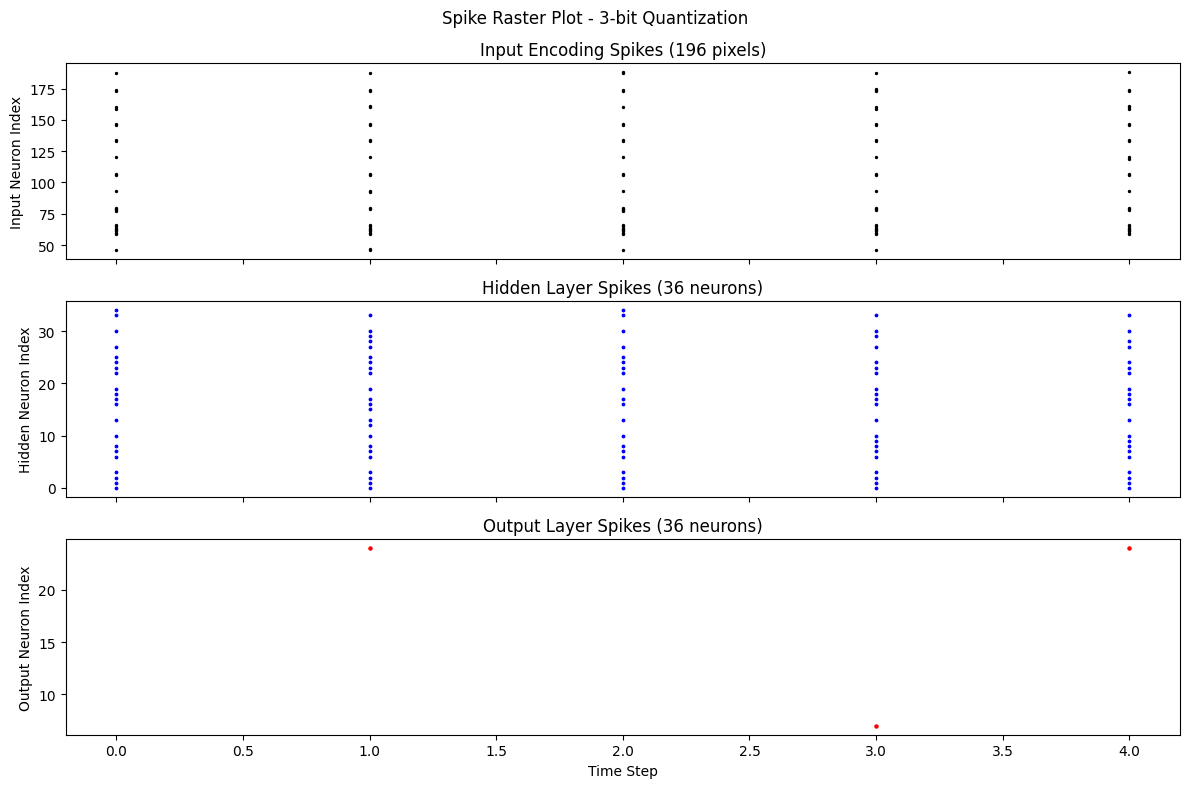


🔧 4-bit Quantization


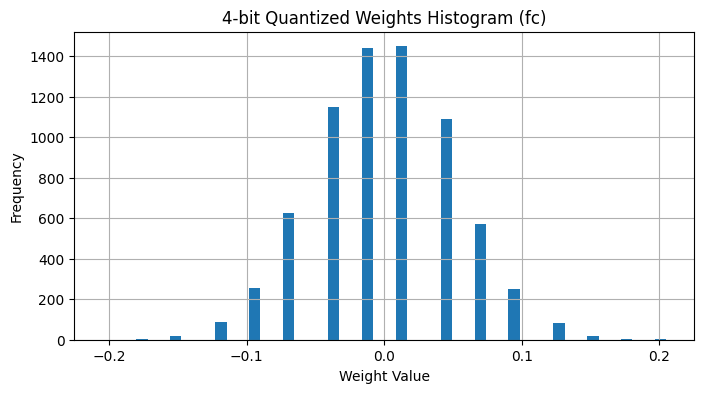

4-bit test accuracy: 26.62%


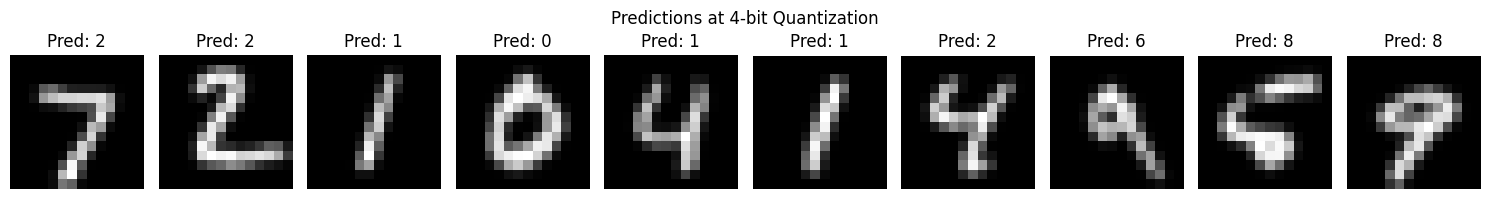

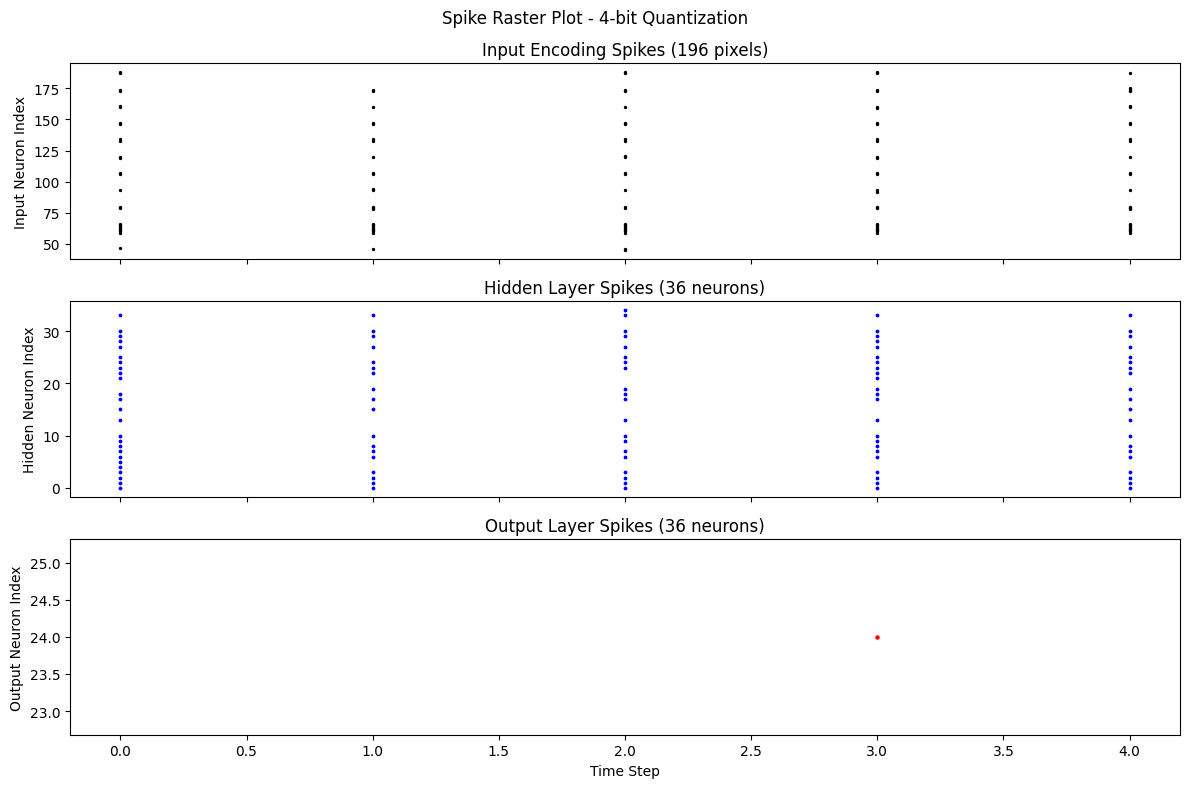


🔧 5-bit Quantization


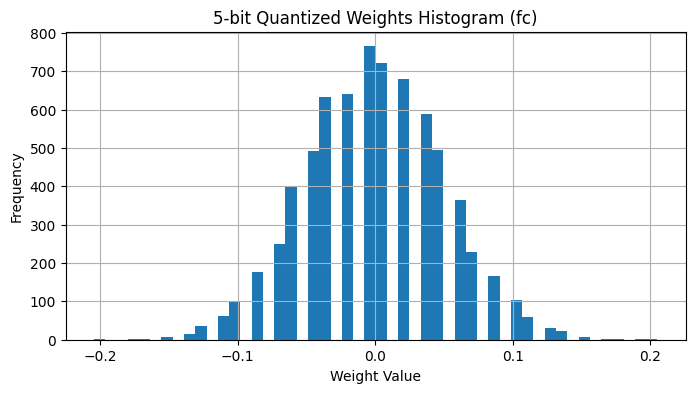

5-bit test accuracy: 26.25%


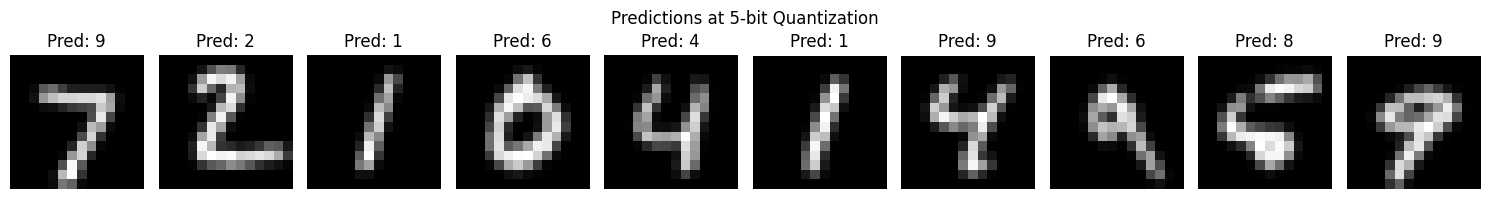

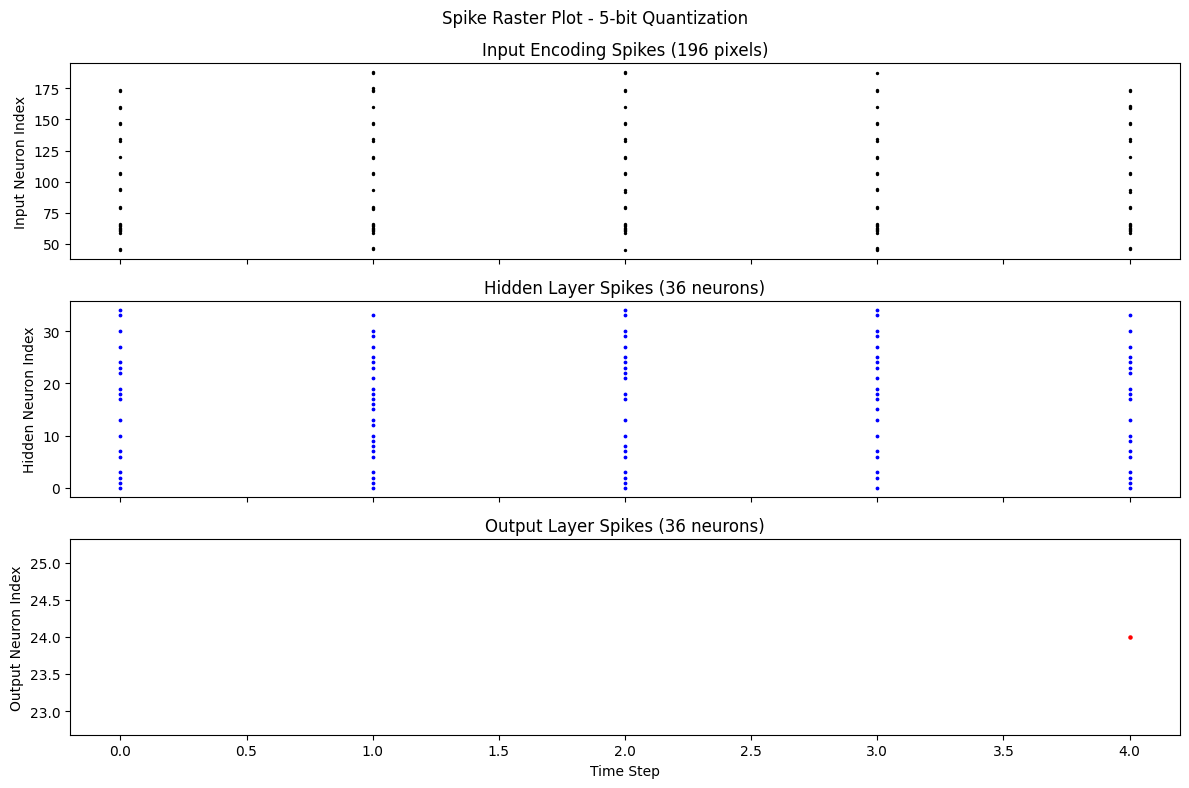

tensor([[-0.0563, -0.0576, -0.0125,  ...,  0.0267,  0.0203,  0.0197],
        [ 0.0086,  0.0438, -0.0144,  ..., -0.0769,  0.0156,  0.0370],
        [ 0.0725,  0.2051,  0.0559,  ...,  0.0136, -0.0463, -0.1366],
        ...,
        [ 0.0039, -0.0924, -0.0043,  ..., -0.0502, -0.0519, -0.0334],
        [ 0.0353, -0.0126, -0.0274,  ...,  0.0387,  0.0199,  0.0273],
        [-0.0399,  0.0208,  0.0221,  ...,  0.0502,  0.0203,  0.0897]])

In [24]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from spikingjelly.activation_based import neuron, encoding, functional

# ========== Setup ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T = 5
lr = 1e-3
trace_decay = 0.9
num_neurons = 36
resize = (14, 14)
input_size = resize[0] * resize[1]

# ========== Load Resized MNIST ==========
transform = transforms.Compose([
    transforms.Resize(resize),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_dataset = torchvision.datasets.MNIST('./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)
test_labels = test_labels.to(device)

# ========== STDPNet Architecture ==========
class STDPNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(input_size, num_neurons, bias=False)
        self.lif = neuron.LIFNode(v_threshold=0.5)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc(x)
        x = self.lif(x)
        return x

# Load pretrained STDPNet (simulated)
model = STDPNet().to(device)
model.eval()

torch.manual_seed(0)
torch.nn.init.normal_(model.fc.weight, mean=0.0, std=0.05)
original_weights = model.fc.weight.data.clone()

# ========== Quantization Function ==========
def quantize_weights(w, bits):
    levels = 2 ** bits
    w_min = w.min()
    w_max = w.max()
    scale = (w_max - w_min) / (levels - 1)
    return torch.round((w - w_min) / scale) * scale + w_min

# ========== Dummy Neuron-to-Label Map ==========
def build_neuron_label_map():
    neuron_activity = torch.zeros((num_neurons, 10))
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            functional.reset_net(model)
            outputs = torch.zeros((images.shape[0], num_neurons)).to(device)
            for t in range(T):
                outputs += model(encoder(images))
            winners = outputs.argmax(dim=1)
            for i in range(images.shape[0]):
                neuron_activity[winners[i], labels[i]] += 1
    return neuron_activity.argmax(dim=1)  # neuron_id -> digit

# ========== Spike Raster Plot ==========
def plot_spike_raster(images, model, encoder, T, title="Spike Raster Plot"):
    model.eval()
    with torch.no_grad():
        functional.reset_net(model)
        input_spike_record = []
        hidden_spike_record = []
        output_spike_record = []

        for t in range(T):
            encoded = encoder(images)
            flat_encoded = encoded.view(encoded.shape[0], -1)
            input_spike_record.append((flat_encoded[0] > 0).float().cpu())

            hidden = model.fc(model.flatten(encoded))
            hidden_spike_record.append((hidden[0] > 0).float().cpu())

            output = model(encoded)
            output_spike_record.append((output > 0).float()[0].cpu())

    input_spikes = torch.stack(input_spike_record)  # [T, 196]
    hidden_spikes = torch.stack(hidden_spike_record)  # [T, num_neurons]
    output_spikes = torch.stack(output_spike_record)  # [T, num_neurons]

    fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axs[0].set_title("Input Encoding Spikes (196 pixels)")
    axs[1].set_title(f"Hidden Layer Spikes ({num_neurons} neurons)")
    axs[2].set_title(f"Output Layer Spikes ({num_neurons} neurons)")

    for t in range(T):
        axs[0].scatter([t] * input_spikes[t].sum().int().item(), torch.where(input_spikes[t] > 0)[0], s=2, color='black')
        axs[1].scatter([t] * hidden_spikes[t].sum().int().item(), torch.where(hidden_spikes[t] > 0)[0], s=3, color='blue')
        axs[2].scatter([t] * output_spikes[t].sum().int().item(), torch.where(output_spikes[t] > 0)[0], s=5, color='red')

    axs[2].set_xlabel("Time Step")
    axs[0].set_ylabel("Input Neuron Index")
    axs[1].set_ylabel("Hidden Neuron Index")
    axs[2].set_ylabel("Output Neuron Index")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# ========== Quantize and Evaluate ==========
bit_levels = [2, 3, 4, 5]
encoder = encoding.PoissonEncoder()

for bits in bit_levels:
    print(f"\n🔧 {bits}-bit Quantization")

    # Quantize weights
    model.fc.weight.data.copy_(quantize_weights(original_weights, bits))

    # Plot histogram of weights
    plt.figure(figsize=(8, 4))
    plt.hist(model.fc.weight.data.cpu().flatten(), bins=50)
    plt.title(f"{bits}-bit Quantized Weights Histogram (fc)")
    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    # Build neuron-to-digit label map
    neuron_label_map = build_neuron_label_map()

    # Evaluate accuracy
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            functional.reset_net(model)
            outputs = torch.zeros((images.shape[0], num_neurons)).to(device)
            for t in range(T):
                outputs += model(encoder(images))
            predicted_neurons = outputs.argmax(dim=1)
            predicted_digits = neuron_label_map[predicted_neurons]
            correct += (predicted_digits == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    print(f"{bits}-bit test accuracy: {acc:.2f}%")

    # Show predictions for test samples
    with torch.no_grad():
        functional.reset_net(model)
        outputs = torch.zeros((test_images.shape[0], num_neurons)).to(device)
        for t in range(T):
            spikes = encoder(test_images)
            outputs += model(spikes)
        outputs /= T
        top_neurons = outputs.argmax(dim=1)
        pred_digits = neuron_label_map[top_neurons]

    fig, axes = plt.subplots(1, 10, figsize=(15, 2))
    fig.suptitle(f"Predictions at {bits}-bit Quantization")
    for i, ax in enumerate(axes):
        ax.imshow(test_images[i].cpu().squeeze(), cmap='gray')
        ax.set_title(f"Pred: {pred_digits[i].item()}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Spike raster for one example
    plot_spike_raster(test_images[0:1], model, encoder, T, title=f"Spike Raster Plot - {bits}-bit Quantization")

# Restore original weights
model.fc.weight.data.copy_(original_weights)


Smaller SNN Accuracy Comparison:



*   Image Size 4x4: Accuracy 52.04%
*   Image Size 7x7: Accuracy 77.58%
*   Image Size 14x14: Accuracy 89.51%
*   Image Size 28x28: Accuracy 91.81%




*  Time Steps: T=5 -> Accuracy: 79.19%    
*  Time Steps: T=10 -> Accuracy: 80.63%
*  Time Steps: T=20 -> Accuracy: 81.06%


*  Training Method: Supervised -> Accuracy: 94.47%
*  Training Method: Unsupervised -> Accuracy: 49.32%


*  Quantization: 2-bit (supervised) -> Accuracy: 48.47%
*  Quantization: 3-bit (supervised) -> Accuracy: 93.75%
*  Quantization: 4-bit (supervised) -> Accuracy: 94.64%
*  Quantization: 5-bit (supervised) -> Accuracy: 94.90%


*  Quantization: 2-bit (unsupervised) -> Accuracy: 24.99%
*  Quantization: 3-bit (unsupervised) -> Accuracy: 25.12%
*  Quantization: 4-bit (unsupervised) -> Accuracy: 26.62%
*  Quantization: 5-bit (unsupervised) -> Accuracy: 26.25%